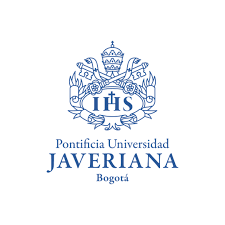


***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### **Taller Métricas y Machine Learning con PySpark**

Autor: María Clara Gómez Romero

ID: 00020552415

Fecha de Inicio: 28 de Abril del 2026.

Fecha actual: 25 de Mayo del 2026.

Materia: Procesamiento de Datos.

Profesor: John Corredor Franco.

Pregrado: Ciencia de Datos.


## **Objetivo:**
- Realizar la metodología completa de tratamiento de datos para implementar modelos de clasificación de Spark ML.
  
### **Caso de Estudio:** 
- Modelo de Comportamiento de Clientes para Depósito a Plazo Fijo en el Banco

#### **Dataset:**
- [Uc Urvine Machine Learning Repository]https://archive.ics.uci.edu/dataset/222/bank+marketing)


#### Puntos del Taller:
- **1. Importación de Bibliotecas y Sesión Spark.**
- **2. Carga del dataset.**
- **3. Descripción y análisis del Dataset.**
- **4. Verificación de la calidad de los Datos.**
- **5. Preparación de los Datos.**
- **6. Limpieza de los Datos.**
- **7. Formato de los Datos.**
- **8. Codificación para la creación de vector ensamblador para las variables categóricas ("features", "target").**
- **9. Modelización: construcción de modelos.**
- **10. Evaluación de los Modelos.**
- **11. Conclusiones.**

### **1. Importación de Bibliotecas y Sesión Spark.**


In [1]:
## Se importan las bibliotecas generales
import os
import sys                              #---> Recursos del Sistema
import pandas as pd                     #---> Para Gráficar y objetos dataframe
import numpy as np                      #---> Para Álgebra matricial
import matplotlib.pyplot as plt         #---> Para Formatos de gráficas
import seaborn as sns                   #---> Para Estadística y ráficar

## Se importan las bibliotecas especializadas
from pylab import *

import findspark
findspark.init()
from pyspark.sql import functions as F
from pyspark import SparkContext, SparkConf         #----> Contexto y configuración de PySpark
from pyspark.sql import SQLContext, SparkSession, Row
from pyspark.sql.types import *

from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml import Pipeline
from sklearn.metrics import roc_curve,auc

In [2]:
### Se requiere levantar la sesión para Trabajar con los Servicios
### Basados en SPARK: Procesamiento Paralelo y Ditribuido sobre Grandes Voluménes de Datos
configura = SparkConf()
configura.setAppName("Banca_Gomez_Spark")
configura.set("spark.scheduler.mode","FAIR")
configura.set("spark.scheduler.allocation","/Almacen/Spark/conf/fairscheduler.xml")
configura.setMaster("spark://10.43.97.207:7077")
sparkGomez = SparkSession.builder.config(conf=configura).getOrCreate()
print("Sesión creada: Banca_Gomez_Spark")

sparkGomez

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/26 01:18:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Sesión creada: Banca_Gomez_Spark


### **2. Carga del dataset.**

In [3]:
# Se crea el dataframe para acceder al sistema de fichero csv como un objeto dataframe PySpark
dfPy00= sparkGomez.read.format("csv").option("header","true").option("sep",";").load("bank-full.csv")
dfPy00.show(5)

[Stage 1:>                                                          (0 + 1) / 1]

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown| single|  unknown|     no|      1|     no|  no|unknown|  5|  may|     19

**3. Descripción y análisis del Dataset.**

In [4]:
### Despliegue de columnas actuales
dfPy00.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

In [5]:
### Conocer los datos
dfPy00.printSchema()

root
 |-- age: string (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: string (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- campaign: string (nullable = true)
 |-- pdays: string (nullable = true)
 |-- previous: string (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



### Detalles del Dataset
##### **1. Descripción de las variables:**
- **AGE:** Edad del Cliente en años.
- **JOB:** Ocupación o tipo del trabajo del cliente (administrativo, obrero, emprendedor, empleada doméstica, gestión, jubilado, autónomo, servicios, estudiante, técnico, desempleado o desconocido).
- **MARITAL:** Estado Cívil del cliente (divorciado, casado, soltero, desconocido; nota: divorciado significa divorciado o viudo).
- **EDUCATION:** Se refiere al nivel educativo del cliente.
- **DEFAULT:** Indica si el cliente tiene crédito en mora (Si/No -> Binario).
- **BALANCE:** Es el saldo anual promedio del cliente en euros.
- **HOUSING:** Indica si el cliente tiene préstamo hipotecario (Si/No -> Binario).
- **LOAN:** Indica si el cliente tiene préstamo personal (Si/No -> Binario).
- **CONTACT:** Tipo de comunicación que se utiliza para contactar al cliente (celular, teléfono).
- **DAY_OF_WEEK:** Se refiere al último día de la semana que se contacto al cliente.
- **MONTH:** Último mes del año en el que se contacto al cliente (ene, feb, mar,.., nov, dic).
- **DURATION:** Duración de la llamada en segundos del último contacto que se tuvo con el cliente.
- **CAMPAIGN:** Número de veces en las que se contacto al cliente para la campaña.
- **PDAYS:** Número de días transcurridos desde la última vez que se contactó al cliente en una campaña anterior (si es -1 -> indica que el cliente no había sido contactado anteriormente).
- **PREVIOUS:** Número de veces en las que se contacto al cliente antes de esta campaña.
- **POUTCOME:** Resultado de la campaña de marketing anterior (fracaso, inexistente, éxito).
- **Y:** Se refiere si el cliente está subscrito a un depósito a plazo fijo (Si/No -> Binario).

##### **2. Análisis del dataset y recomendaciones:**
- Se observa que todos los datos se encuentran en tipo String.
- Por lo tanto, se considera necesario hacer el cambio del tipo de de dato para algunas de las variables, hacia double o entero.
- Por otro lado, se identificó que la última columna contiene una variable de tipo etiqueta.

In [6]:
### Coherencia de los datos
### Se cambia el age, balance, day, duration,campaign, pdays,previosus por tipo de dato entero
colINT = ['age', 'balance','day', 'duration','campaign','pdays','previous']

dfPy01 = dfPy00.withColumn("age", dfPy00.age.cast("int"))
dfPy01 = dfPy01.withColumn("balance", dfPy01.balance.cast("int"))
dfPy01 = dfPy01.withColumn("day", dfPy01.day.cast("int"))
dfPy01 = dfPy01.withColumn("duration", dfPy01.duration.cast("int"))
dfPy01 = dfPy01.withColumn("campaign", dfPy01.campaign.cast("int"))
dfPy01 = dfPy01.withColumn("pdays", dfPy01.pdays.cast("int"))
dfPy01 = dfPy01.withColumn("previous", dfPy01.previous.cast("int"))

dfPy01.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



In [7]:
## Se revisa el balance del dataset, la idea es conocer si hay posibilidades de SESGO
total = dfPy01.count()
df_Y = dfPy01.groupBy("y").count()


auxPD = df_Y.withColumn("Porcentaje", df_Y["count"]*100/total)

auxPD.show()

[Stage 5:=============================>                             (1 + 1) / 2]

+---+-----+------------------+
|  y|count|        Porcentaje|
+---+-----+------------------+
| no|39922| 88.30151954170445|
|yes| 5289|11.698480458295547|
+---+-----+------------------+



### Comentarios:
- Al observar el balance de la columna target. Se encuentra que hay un desbalance, ya que la clase mayoritaria es "no", con un 88.3%, representando 39922 registros. Mientras que la "yes" es la clase minoritaria con un 11.7%, representando 5289 registros.
- Como la variable es binaria, se debe tener en cuenta no crear un sesgo al tratar los modelos para hacer la predicción.

In [8]:
### Se revisa de forma exahustiva las estadísticas completas del dataset
dfPy01.describe().toPandas()

26/05/26 01:19:09 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,summary,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975401,None,None,None,None,3044.7658291685243,None,None,None,8.322476153044589,None,257.5278122651712,3.0980208832791813,100.12874599059818,2.3034410449312164,None,None
3,min,18,admin.,divorced,primary,no,-8019,no,no,cellular,1,apr,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,102127,yes,yes,unknown,31,sep,4918,63,871,275,unknown,yes


### Comentarios:
**- Se observa las estadísticas de los valores nominales:**
- Se puede hacer las presentaciones convertidas en objetos PANDAS, siempre que sean DF pequeños. Los DF pandas consumen mucha memoria.

**- En relación a la edad:**
- Se puede observar que las personas se encuentran entre 18 y 95 años.
- El promedio de edad esta en 40 años aproximadamente.
- La variación es de 10 años alrededor de los 40 años.
    
**- En relación al trabajo:**
- La categoría Administrador es la que menos aparece.
- La categoría Unknow es la que más se repite: la mayor parte de los registros se desconoe en que trabaja.

**- En relación a la variable duration (tiempo de la llamada en segundos):**
- Se observa que el promedio de duración de llamadas es de 258s aproximadamente.
- La dispersión de 257 segundos.
- Esto refleja que el tiempo promedio y la desviación al ser similares.
  
**- En relación a la variable contact:**(Cantidad de veces que contactan al cliente en una "Campaign")
- Se observa que el promedio de aproximadamente 2.76.
  
**- En relación a la variable balance:** (cuenta o balance de los cada cliente)
- Se observa que el promedio de aproximadamente 1362 Euros.

#### **Se requiere observar en detalle las variables Categóricas**

    - Se agrupa cada categoría y se cuenta el número de ocurrencias en cada grupo.

In [9]:
####Seleccionar solo las variables categoricas
col_cat = ['job', 'marital','education', 'default', 'housing',
           'loan', 'contact','month', 'poutcome','y']

#Se agrupa y se observa cada categoria
for col in col_cat:
    dfPy01.groupBy(col).count().show()

+-------------+-----+
|          job|count|
+-------------+-----+
|   management| 9458|
|      retired| 2264|
|      unknown|  288|
|self-employed| 1579|
|      student|  938|
|  blue-collar| 9732|
| entrepreneur| 1487|
|       admin.| 5171|
|   technician| 7597|
|     services| 4154|
|    housemaid| 1240|
|   unemployed| 1303|
+-------------+-----+

+--------+-----+
| marital|count|
+--------+-----+
|divorced| 5207|
| married|27214|
|  single|12790|
+--------+-----+

+---------+-----+
|education|count|
+---------+-----+
|  unknown| 1857|
| tertiary|13301|
|secondary|23202|
|  primary| 6851|
+---------+-----+

+-------+-----+
|default|count|
+-------+-----+
|     no|44396|
|    yes|  815|
+-------+-----+

+-------+-----+
|housing|count|
+-------+-----+
|     no|20081|
|    yes|25130|
+-------+-----+

+----+-----+
|loan|count|
+----+-----+
|  no|37967|
| yes| 7244|
+----+-----+

+---------+-----+
|  contact|count|
+---------+-----+
|  unknown|13020|
| cellular|29285|
|telephone| 2906|
+

### Comentarios:

#### Se requiere observar en gráficas las variables númericas ****(Histogramas)****
    - Se agrupa cada categoría y se cuenta el número de ocurrencias en cada grupo.
    - Se gráfica usando las gráficas de histogramas, para principalmente para representar y comparar frecuencias o cantidades entre categorías. En procesamiento y análisis de datos, son muy útiles para visualizar variables categóricas o discretas.
    - En el contexto del taller, son útiles para comparar categorías, visualizar distribuciones, detectar patrones y tendencias e identificar valores atípicos.

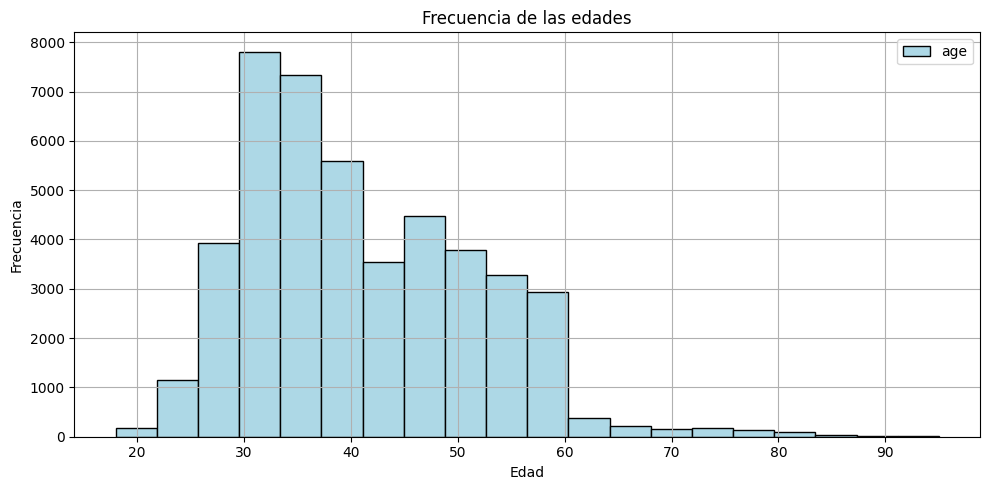

In [10]:
histogram = dfPy01.select('age').toPandas()
histogram.plot(kind='hist', bins=20, edgecolor='black', color='lightblue', figsize=(10, 5))
plt.ylabel('Frecuencia')
plt.xlabel('Edad')
plt.title('Frecuencia de las edades')
plt.tight_layout()
plt.grid()
plt.show()

#### ****Análisis:**** *age* | **#1. Frecuencia de las edades:** 
- La mayor concentración de clientes se encuentra entre los 30 y 50 años.
- Pocos registros de clientes muy jóvenes o mayores de 80 años.
- Existen algunos posibles valores atípicos mayores a 70 años.

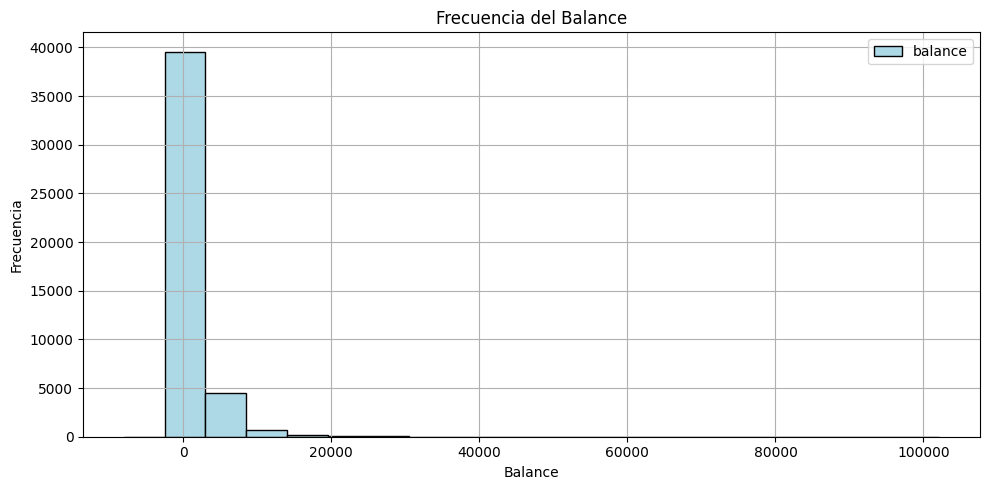

In [11]:
histogram = dfPy01.select('balance').toPandas()
histogram.plot(kind='hist', bins=20, edgecolor='black', color='lightblue', figsize=(10, 5))
plt.ylabel('Frecuencia')
plt.xlabel('Balance')
plt.title('Frecuencia del Balance')
plt.tight_layout()
plt.grid()
plt.show()

#### ****Análisis:**** *balance* | **#2. Frecuencia del Balance:** 
- La mayoría de los clientes poseen balances bajos o cercanos a cero.
- Se observan valores atípicos muy altos.
- La variable podría requerir transformación o tratamiento de outliers para el modelamiento.

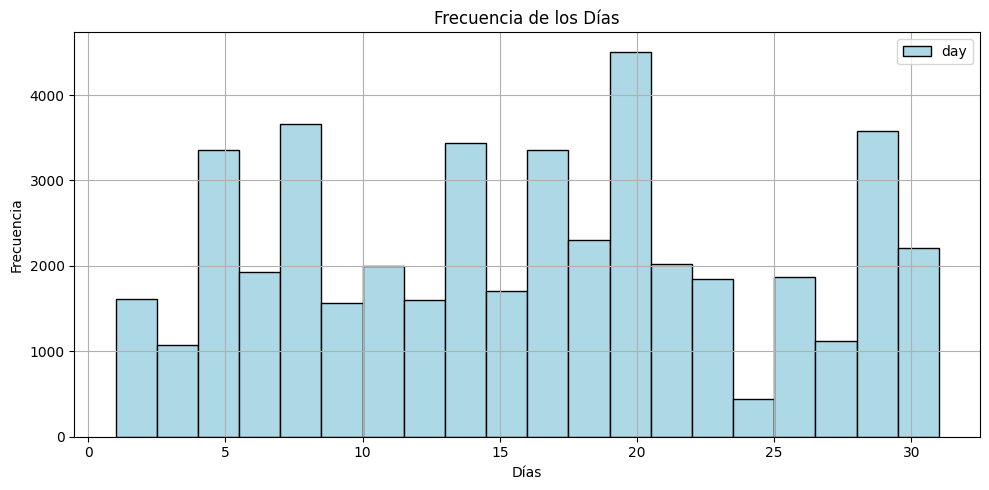

In [12]:
histogram = dfPy01.select('day').toPandas()
histogram.plot(kind='hist', bins=20, edgecolor='black', color='lightblue', figsize=(10, 5))
plt.ylabel('Frecuencia')
plt.xlabel('Días')
plt.title('Frecuencia de los Días')
plt.tight_layout()
plt.grid()
plt.show()

#### ****Análisis:**** *day* | **#3. Frecuencia de los días:** 
- Los contactos no se distribuyen uniformemente durante los días.
- Se presentan picos de frecuencia alrededor de ciertos días, especialmente cerca del día 20.
- No se observan valores fuera del rango esperado.
- La variable podría reflejar estrategias operativas de la campaña.

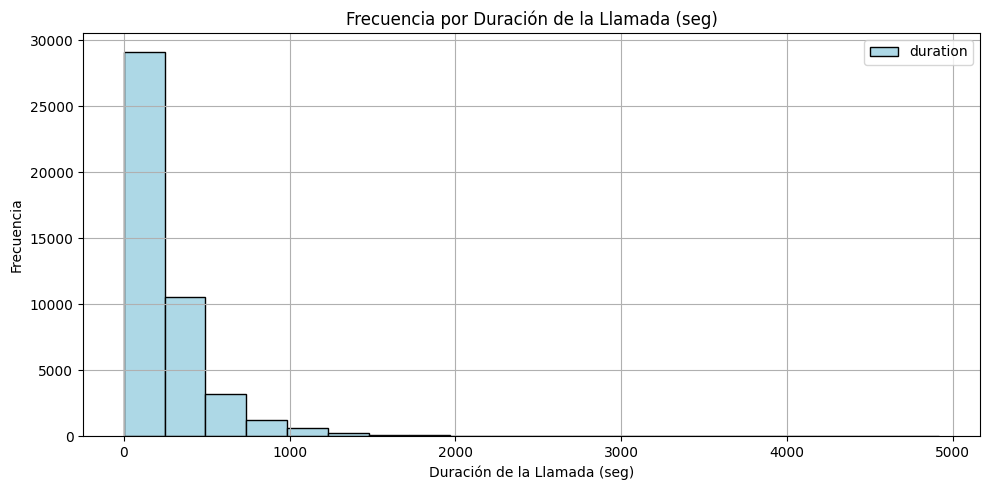

In [13]:
histogram = dfPy01.select('duration').toPandas()
histogram.plot(kind='hist', bins=20, edgecolor='black', color='lightblue', figsize=(10, 5))
plt.ylabel('Frecuencia')
plt.xlabel('Duración de la Llamada (seg)')
plt.title('Frecuencia por Duración de la Llamada (seg)')
plt.tight_layout()
plt.grid()
plt.show()

#### ****Análisis:**** *duration* | **#4. Frecuencia por Duración de la llamada** (en segundos del último contacto que se tuvo con el cliente)**:**
- La mayoría de las llamadas tienen corta duración, ya que, duran menos de 500 seg, con un pico entre 0 y 200 seg.
- La distribución presenta fuerte sesgo hacia la derecha.
- Existen llamadas con duraciones extremadamente altas (outliers).
- La variable puede ser muy predictiva, pero también puede generar sesgo o fuga de información en el modelo.

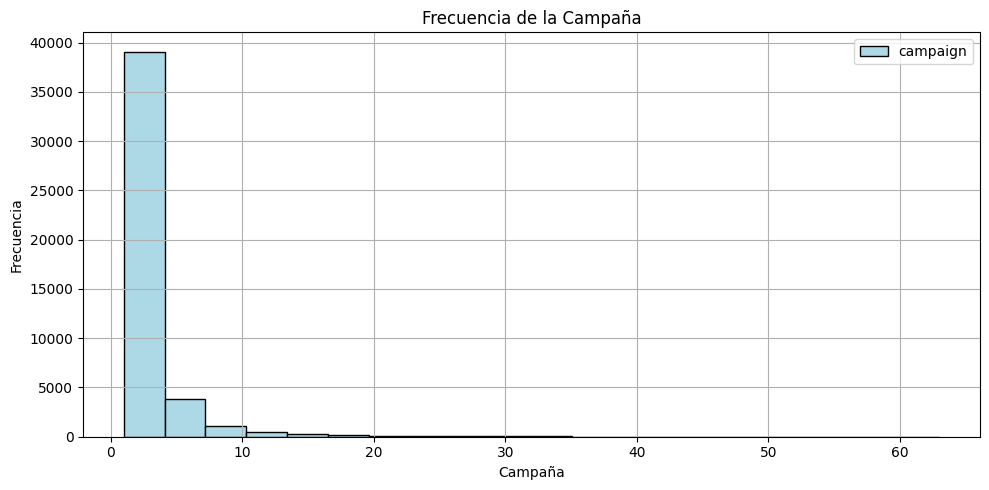

In [14]:
histogram = dfPy01.select('campaign').toPandas()
histogram.plot(kind='hist', bins=20, edgecolor='black', color='lightblue', figsize=(10, 5))
plt.ylabel('Frecuencia')
plt.xlabel('Campaña')
plt.title('Frecuencia de la Campaña')
plt.tight_layout()
plt.grid()
plt.show()

#### ****Análisis:**** *campaign* | **#5. Frecuencia de la Campaña** (# de veces en las que se contacto al cliente para la campaña)**:** 
- La mayor frecuencia de datos se encuentra entre 1 y 5 contactos.
- La distribución tiene una cola larga hacia la derecha.
- Existen clientes con una cantidad muy alta de contactos.
- La mayoría de clientes fueron contactados pocas veces, mientras que un grupo reducido recibió muchos intentos de contacto.

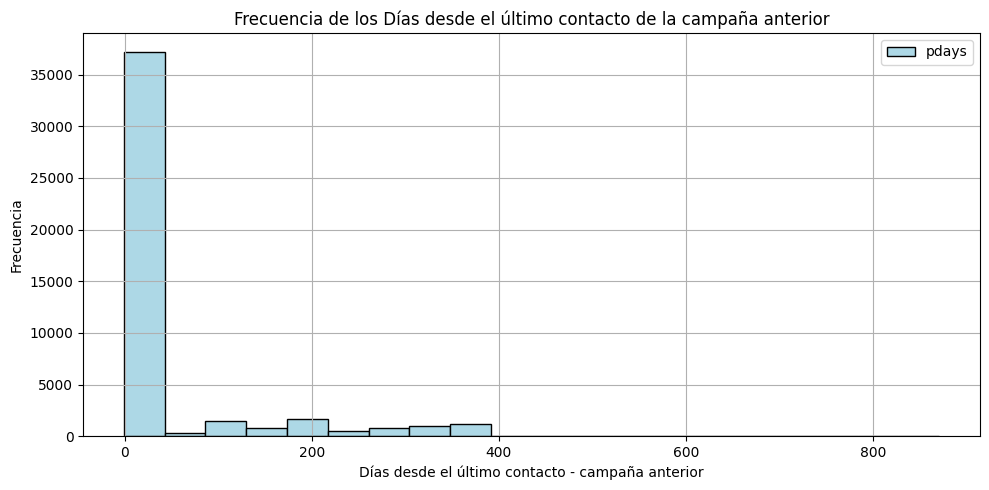

In [15]:
histogram = dfPy01.select('pdays').toPandas()
histogram.plot(kind='hist', bins=20, edgecolor='black', color='lightblue', figsize=(10, 5))
plt.ylabel('Frecuencia')
plt.xlabel('Días desde el último contacto - campaña anterior')
plt.title('Frecuencia de los Días desde el último contacto de la campaña anterior')
plt.tight_layout()
plt.grid()
plt.show()

#### ****Análisis:**** *pdays* | **#6. Frecuencia de los Días desde el último contacto de la campaña anterior:**
- La distribución presenta una gran concentración de valores cercanos a 0.
- Existe una fuerte asimetría positiva (sesgo hacia la derecha).
- Se observan pocos registros con valores altos (más de 100, 200 y hasta cerca de 400 días).
- La mayoría de clientes aparentemente fueron contactados recientemente, o nunca habían sido contactados anteriormente.

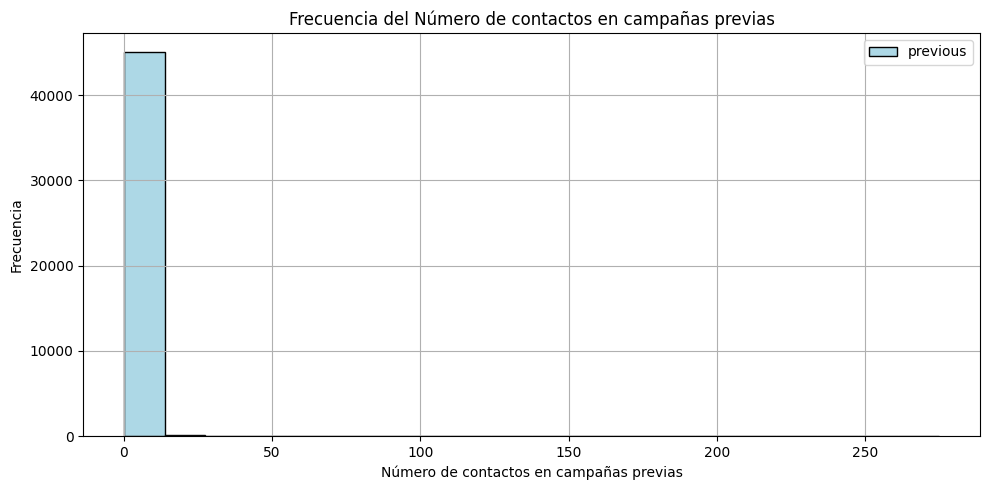

In [16]:
histogram = dfPy01.select('previous').toPandas()
histogram.plot(kind='hist', bins=20, edgecolor='black', color='lightblue', figsize=(10, 5))
plt.ylabel('Frecuencia')
plt.xlabel('Número de contactos en campañas previas')
plt.title('Frecuencia del Número de contactos en campañas previas')
plt.tight_layout()
plt.grid()
plt.show()

#### ****Análisis:**** *previous* | **#7. Frecuencia del Número de contactos en campañas previas:**
- La mayoría de los registros se concentran en valores cercanos a 0.
- Existen pocos casos con valores muy altos.
- La distribución presenta un fuerte sesgo positivo.
- La mayoría de clientes, no habían sido contactados anteriormente, o tuvieron pocos contactos previos.

#### **Se requiere análizar a fondo las variables numéricas** ****(Boxplot)****

    - Se agrupa cada variable numérica y se grafica con el tipo de gráfica BOXPLOT.
    - Las gráficas boxplot o diagrama de caja y bigotes es una gráfica utilizada en el análisis de datos para representar la distribución de una variable numérica y detectar valores atípicos (outliers).
    - En procesamiento de datos, el boxplot es muy útil porque resume visualmente la información estadística más importante de una variable.
    - Asimismo, dentro del contexto de este taller, es funcional para detectar outliers, analizar la dispersión, comparar variables e identificar asimetría.

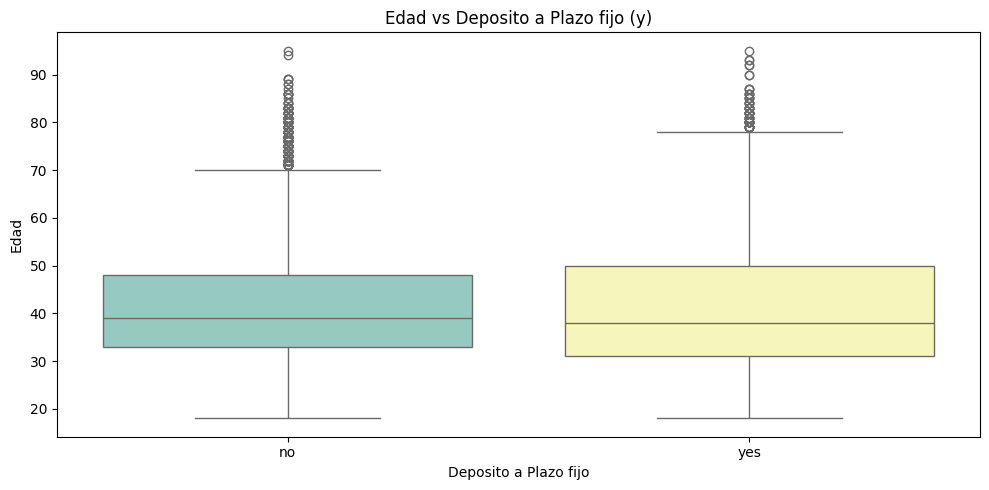

In [17]:
df01 = dfPy01.toPandas()

plt.figure(figsize=(10, 5))
sns.boxplot(x='y', y='age', data=df01, hue='y', palette='Set3', legend=False)
plt.title('Edad vs Deposito a Plazo fijo (y)')
plt.xlabel('Deposito a Plazo fijo')
plt.ylabel('Edad')
plt.tight_layout()
plt.show()

#### ****Análisis:**** *age*  | **#1. Edad Vs Depósito a plazo fijo:** 
- La mediana de edad de los clientes que sí adquirieron el depósito (yes) es ligeramente mayor que la de quienes no lo hicieron (no).
- En ambos grupos la mayoría de edades se concentra aproximadamente entre los 30 y 50 años.
- Se observan numerosos valores atípicos (outliers) en edades superiores a los 70 años.
- El grupo yes presenta una dispersión ligeramente mayor.
- La edad parece tener cierta relación con la decisión de suscribirse al depósito.
- Los clientes de mayor edad podrían mostrar mayor interés en productos financieros estables como los depósitos a plazo fijo.
- Sin embargo, existe bastante superposición entre ambos grupos, por lo que la edad por sí sola no sería una variable totalmente determinante.

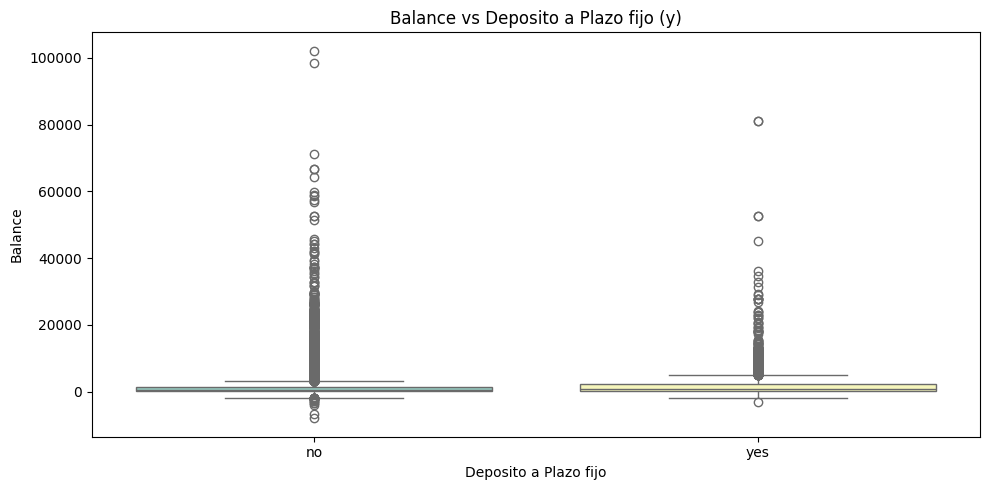

In [18]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='y', y='balance', data=df01, hue='y', palette='Set3', legend=False)
plt.title('Balance vs Deposito a Plazo fijo (y)')
plt.xlabel('Deposito a Plazo fijo')
plt.ylabel('Balance')
plt.tight_layout()
plt.show()

#### ****Análisis:**** *balance*  | **#2. Balance Vs Depósito a plazo fijo:** 
- La distribución del saldo (BALANCE) presenta una gran cantidad de valores extremos.
- Existen clientes con balances muy altos, superiores incluso a los 100.000 euros.
- Los clientes que aceptaron el depósito (yes) muestran una mediana de balance ligeramente superior.
- Los clientes con mayor saldo promedio parecen tener mayor probabilidad de suscribirse al depósito.
- El fuerte sesgo y la presencia de outliers indican que la variable no sigue una distribución normal.

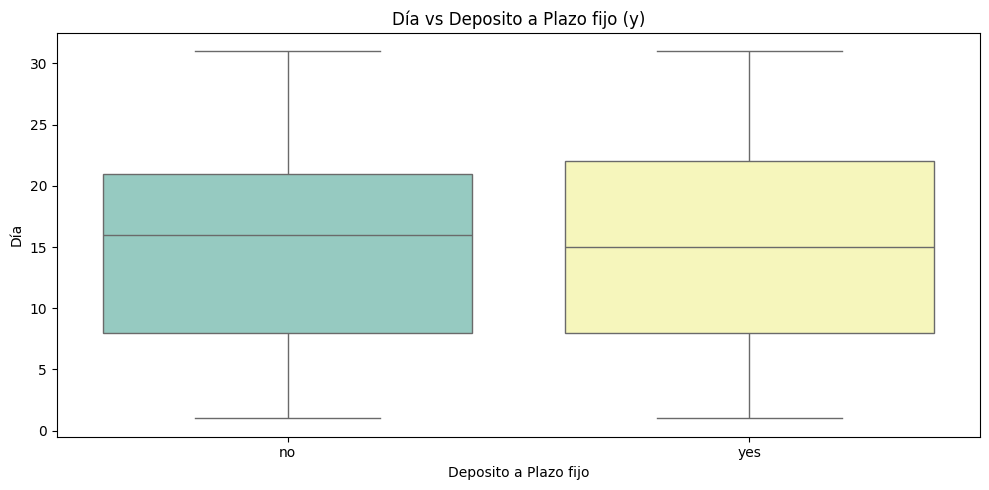

In [19]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='y', y='day', data=df01, hue='y', palette='Set3', legend=False)
plt.title('Día vs Deposito a Plazo fijo (y)')
plt.xlabel('Deposito a Plazo fijo')
plt.ylabel('Día')
plt.tight_layout()
plt.show()

#### ****Análisis:**** *day*  | **#3. Día Vs Depósito a plazo fijo:** 
- La mediana se encuentra aproximadamente entre los días 15 y 16.
- No se observan diferencias significativas entre ambos grupos.
- La dispersión es prácticamente igual.
- El día del contacto no parece influir considerablemente en la decisión del cliente.
- Esta variable podría tener baja importancia predictiva dentro del modelo.

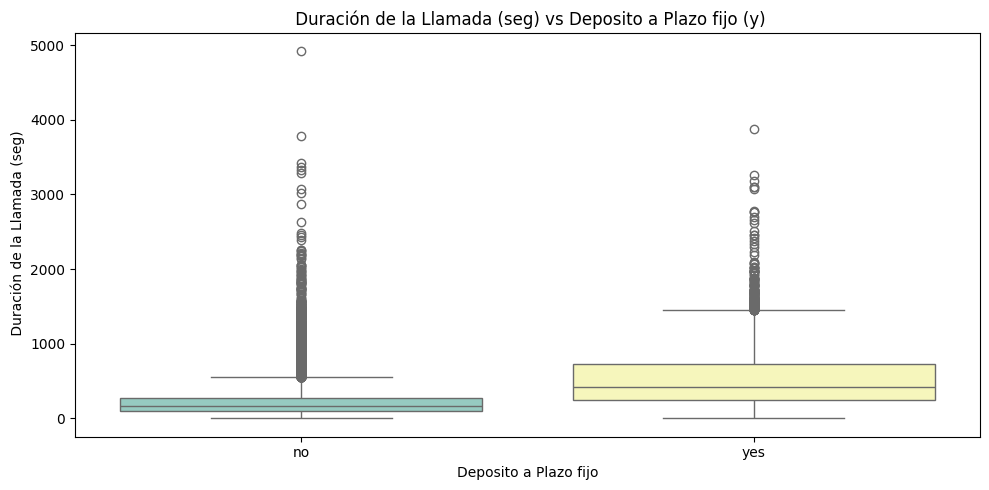

In [20]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='y', y='duration', data=df01, hue='y', palette='Set3', legend=False)
plt.title(' Duración de la Llamada (seg) vs Deposito a Plazo fijo (y)')
plt.xlabel('Deposito a Plazo fijo')
plt.ylabel(' Duración de la Llamada (seg)')
plt.tight_layout()
plt.show()

#### ****Análisis:**** *duration*  | **#4. Duración de la Llamada (seg) Vs Depósito a plazo fijo:** 
- Los clientes que sí contrataron el depósito (yes) presentan una mediana de duración de llamada considerablemente mayor que aquellos que no contrataron (no).
- La caja del grupo yes está desplazada hacia valores más altos, indicando que las llamadas exitosas suelen durar más tiempo.
- Existen numerosos valores atípicos en ambos grupos, especialmente en no, con llamadas extremadamente largas.
- La dispersión de los datos también es mayor en el grupo yes.
- La variable DURATION parece tener una relación fuerte con la variable objetivo Y. Por lo que las Llamadas más largas aumentan la probabilidad de suscripción al depósito a plazo fijo

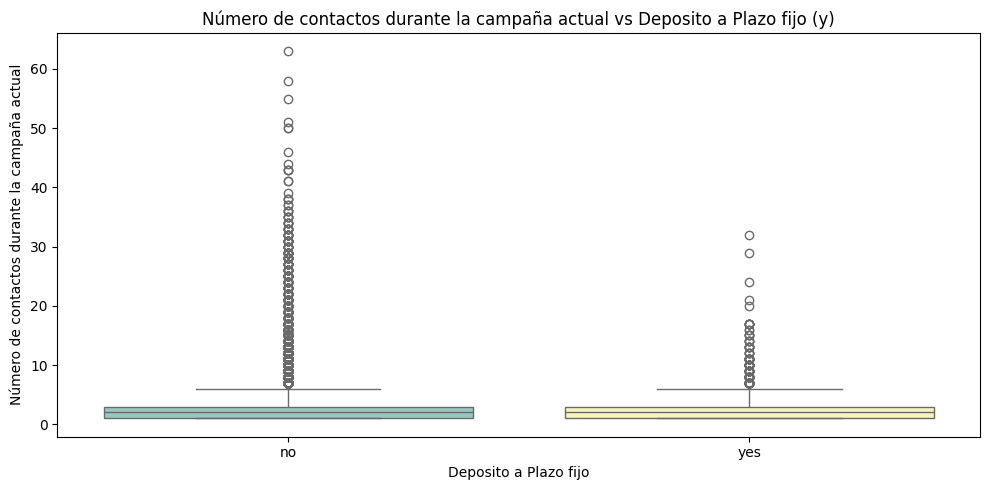

In [21]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='y', y='campaign', data=df01, hue='y', palette='Set3', legend=False)
plt.title('Número de contactos durante la campaña actual vs Deposito a Plazo fijo (y)')
plt.xlabel('Deposito a Plazo fijo')
plt.ylabel('Número de contactos durante la campaña actual')
plt.tight_layout()
plt.show()

#### ****Análisis:**** *campaign*  | **#5. Número de contactos durante la campaña actual Vs Depósito a plazo fijo:** 
- La mediana del número de contactos es similar en ambos grupos, aunque ligeramente menor en los clientes que sí aceptaron el depósito.
- Los clientes del grupo no presentan muchos más valores extremos, alcanzando más de 60 contactos.
- El grupo yes se encuentra más concentrado.

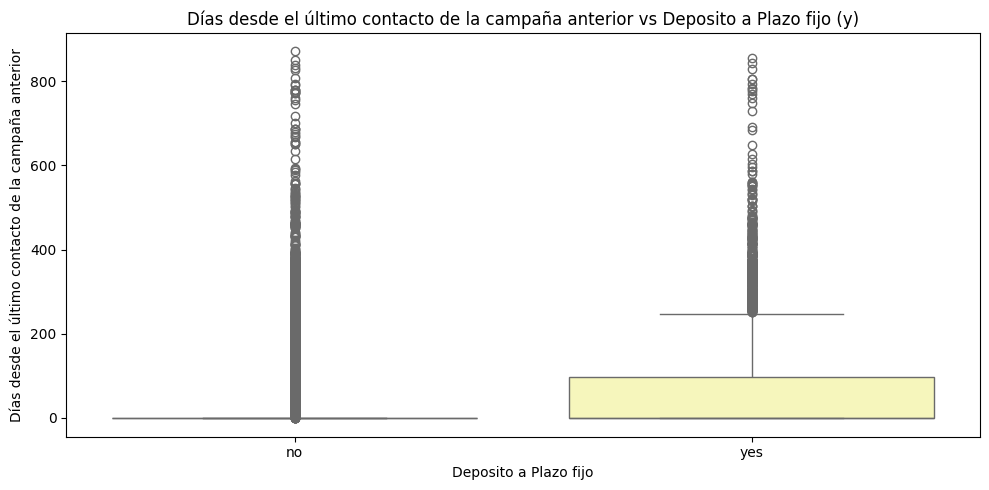

In [22]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='y', y='pdays', data=df01, hue='y', palette='Set3', legend=False)
plt.title('Días desde el último contacto de la campaña anterior vs Deposito a Plazo fijo (y)')
plt.xlabel('Deposito a Plazo fijo')
plt.ylabel('Días desde el último contacto de la campaña anterior')
plt.tight_layout()
plt.show()

#### ****Análisis:**** *pdays*  | **#6. Días desde el último contacto de la campaña anterior Vs Depósito a plazo fijo:** 
- En el grupo yes se observa una mayor dispersión y valores más altos de PDAYS.
- Muchos registros del grupo no se concentran cerca de 0.
- Existen numerosos valores atípicos en ambos grupos.
- Valores pequeños indican contacto reciente.
- Valores grandes indican que pasó mucho tiempo desde el último contacto.

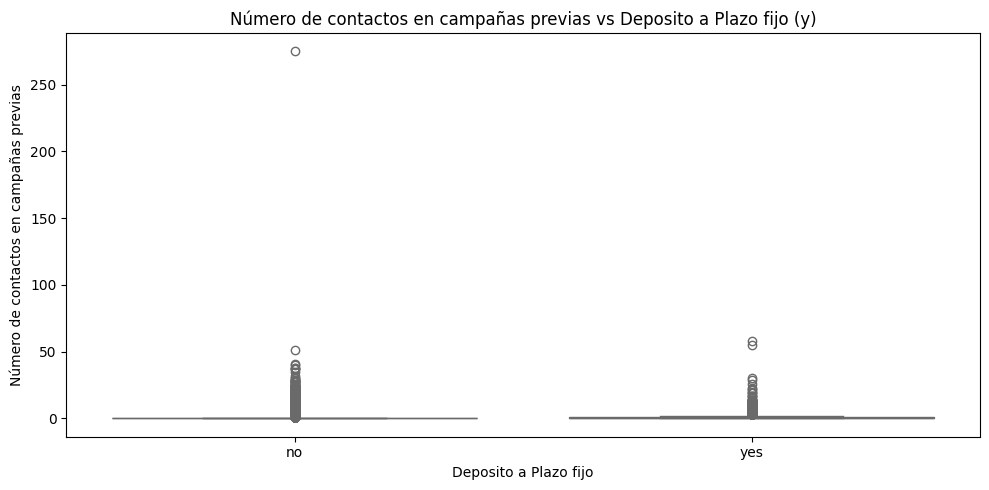

In [23]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='y', y='previous', data=df01, hue='y', palette='Set3', legend=False)
plt.title('Número de contactos en campañas previas vs Deposito a Plazo fijo (y)')
plt.xlabel('Deposito a Plazo fijo')
plt.ylabel('Número de contactos en campañas previas')
plt.tight_layout()
plt.show()

#### ****Análisis:**** *previous*  | **#7. Número de contactos en campañas previas Vs Depósito a plazo fijo:** 
- La mayoría de los clientes presentan valores bajos en PREVIOUS, especialmente cercanos a 0.
- Tanto los clientes que contrataron el depósito (“yes”) como los que no (“no”) muestran una gran concentración en valores pequeños.
- Existen numerosos outliers, principalmente en la categoría “no”, donde algunos clientes fueron contactados muchas veces anteriormente.
- Se observa que los clientes que aceptaron el depósito (“yes”) presentan algunos valores moderadamente altos, pero en menor cantidad.
- La variable sigue siendo útil porque representa el historial de interacción con el cliente.

#### **Conclusiones Generales:**
- La edad de las personas con las que se establece contacto oscila entre los 30 y los 50 años, y a partir de los 70 años se consideran valores atípicos.
- La duración de los contactos es de aproximadamente 700 segundos, y los valores superiores a 1500 segundos ya se consideran valores atípicos.
- Se establece un contacto por persona, y a partir de 8 contactos ya se consideran valores atípicos.
- El saldo medio de las personas contactadas es de 1000 euros, y los valores que superan los 1500 euros ya se consideran valores atípicos.
- Los contactos se realizaron principalmente entre el 8 y el 21 de cada mes, y los clientes que realizan ingresos son contactados previamente en una campaña anterior, 100 días antes de la campaña objeto de estudio.
- El número de contactos realizados antes de esta campaña para el cliente fue en su mayoría 0, y los valores restantes son valores atípicos.

### Entendimiento de los datos númericos: Matriz de Correlación
- Se requiere hacer un objeto dataframe auxiliar con sólo las columnas numéricas.
- La variable "y" o variable independiente, se requiere pasar 'yes' == 1.
- **Matriz de Correlación:** La matriz de correlación permite medir la relación lineal entre las variables numéricas.

In [24]:
colNUM = ['age', 'balance','day', 'duration','campaign','pdays','previous']

### Se requiere cambiar la columna "y" de si o no a 0 y 1
### Adicional se requiere incorporarla al dataframe nummérico
dfauxNUM = dfPy01.select(colNUM + ['y'])
dfauxNUM = dfauxNUM.withColumn('y', F.when(dfauxNUM['y'] == 'yes',1).otherwise(0))
dfauxNUM.show(5)

+---+-------+---+--------+--------+-----+--------+---+
|age|balance|day|duration|campaign|pdays|previous|  y|
+---+-------+---+--------+--------+-----+--------+---+
| 58|   2143|  5|     261|       1|   -1|       0|  0|
| 44|     29|  5|     151|       1|   -1|       0|  0|
| 33|      2|  5|      76|       1|   -1|       0|  0|
| 47|   1506|  5|      92|       1|   -1|       0|  0|
| 33|      1|  5|     198|       1|   -1|       0|  0|
+---+-------+---+--------+--------+-----+--------+---+
only showing top 5 rows



In [25]:
### El anterior dataframe auxiliar se convierte en un VectorAssembler de 'feature'
### (Fijate que se incorpora la variable "y" con los númericos para hacer el vector)
### La idea es que con el vector se pueda representar escalada/normalizada la matriz de correlación
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.ml.stat import Correlation
Ensamblador = VectorAssembler(inputCols = dfauxNUM.columns, outputCol='features')

##Normalizado y Escalado
dfNumVector =  Ensamblador.transform(dfauxNUM).select('features')


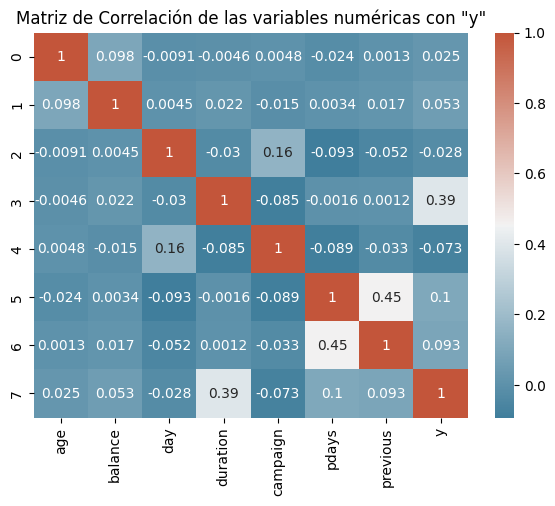

In [26]:
### Se gráfica la matriz de correlación: se tiene en cuenta que los datos son ensamblados
matrizCorr = Correlation.corr(dfNumVector, 'features').head()

## Se procede a pintar la matriz de correlación
vectorCorr = matrizCorr[0].toArray()

## Se crea un objeto dataframe con el arreglo anterior de Correlación de Pearson
dfCorrelation = pd.DataFrame(vectorCorr, columns = dfauxNUM.columns)

# Generate a custom divering colormap
cmapM = sns.diverging_palette(230,20,as_cmap=True)

plt.figure(figsize=(7,5))
sns.heatmap(dfCorrelation,
           annot=True,
           cmap = cmapM)
plt.title('Matriz de Correlación de las variables numéricas con "y"')
plt.show()

### Comentarios:
- **“Duration** VS **Y:**

La correlación de 0,39 entre la variable «Duración» y la variable objetivo **Y** *(depósito)* sugiere una relación moderada entre ambas variables.

En este contexto, una correlación positiva razonablemente fuerte indica que la duración de las llamadas tiene cierto impacto en la variable objetivo, posiblemente en la contratación de depósitos a plazo.

La variable «Duración» puede ser un indicador, lo que sugiere que es una variable prometedora y puede ser un factor relevante en la contratación de la suscripción.

Se recomienda mantener esta variable, ya que parece tener una relación relevante con el resultado que intentamos predecir, es decir, la contratación del depósito a plazo.


- **"PDAYS"** Vs **"Previous"**

La correlación de 0,45 entre las variables «pdays» (número de días desde el último contacto) y «Previous» (número de contactos anteriores) indica una relación de moderada a fuerte entre estas dos variables.

Esto sugiere que existe una asociación considerable entre el número de días transcurridos desde el último contacto y el número de contactos anteriores realizados con un cliente específico.

Para la construcción de modelos predictivos, será interesante eliminar una de estas variables correlacionadas.

- **"Las demás correlaciones"**
Las demás variables presentan correlaciones cercanas a cero.

No existe una relación lineal fuerte entre variables como: age,balance,day,campaign,y la variable objetivo.

Aunque la correlación lineal sea baja, estas variables aún pueden aportar información útil en modelos no lineales o combinadas con otras variables.

- **Consideraciones**
- Se eliminará la variable «PDAYS».

- En ocasiones, las variables altamente correlacionadas pueden introducir multicolinealidad en los modelos, lo que puede afectar negativamente al rendimiento.

- Impacto de la variable cuantitativa «duración» en la variable objetivo «depósito»

 ### Se requiere hacer un gráfico sobre todas las variables
 ##### **Graphic Pairplot:** El pairplot permite observar distribuciones y relaciones entre variables numéricas diferenciando los clientes que contrataron (“yes”) y los que no (“no”).

- PAIR PLOT es una cuadrícula de gráficos de dispersión que muestra las relaciones entre las variables por pares.

- Cada celda de la cuadrícula muestra la relación entre una variable y la otra en función de la variable objetivo.

- El parámetro HUE = «deposit» se utiliza para colorear los puntos en función de la variable objetivo «deposit», lo que facilita la comprensión de las relaciones entre las variables numéricas y la variable objetivo.


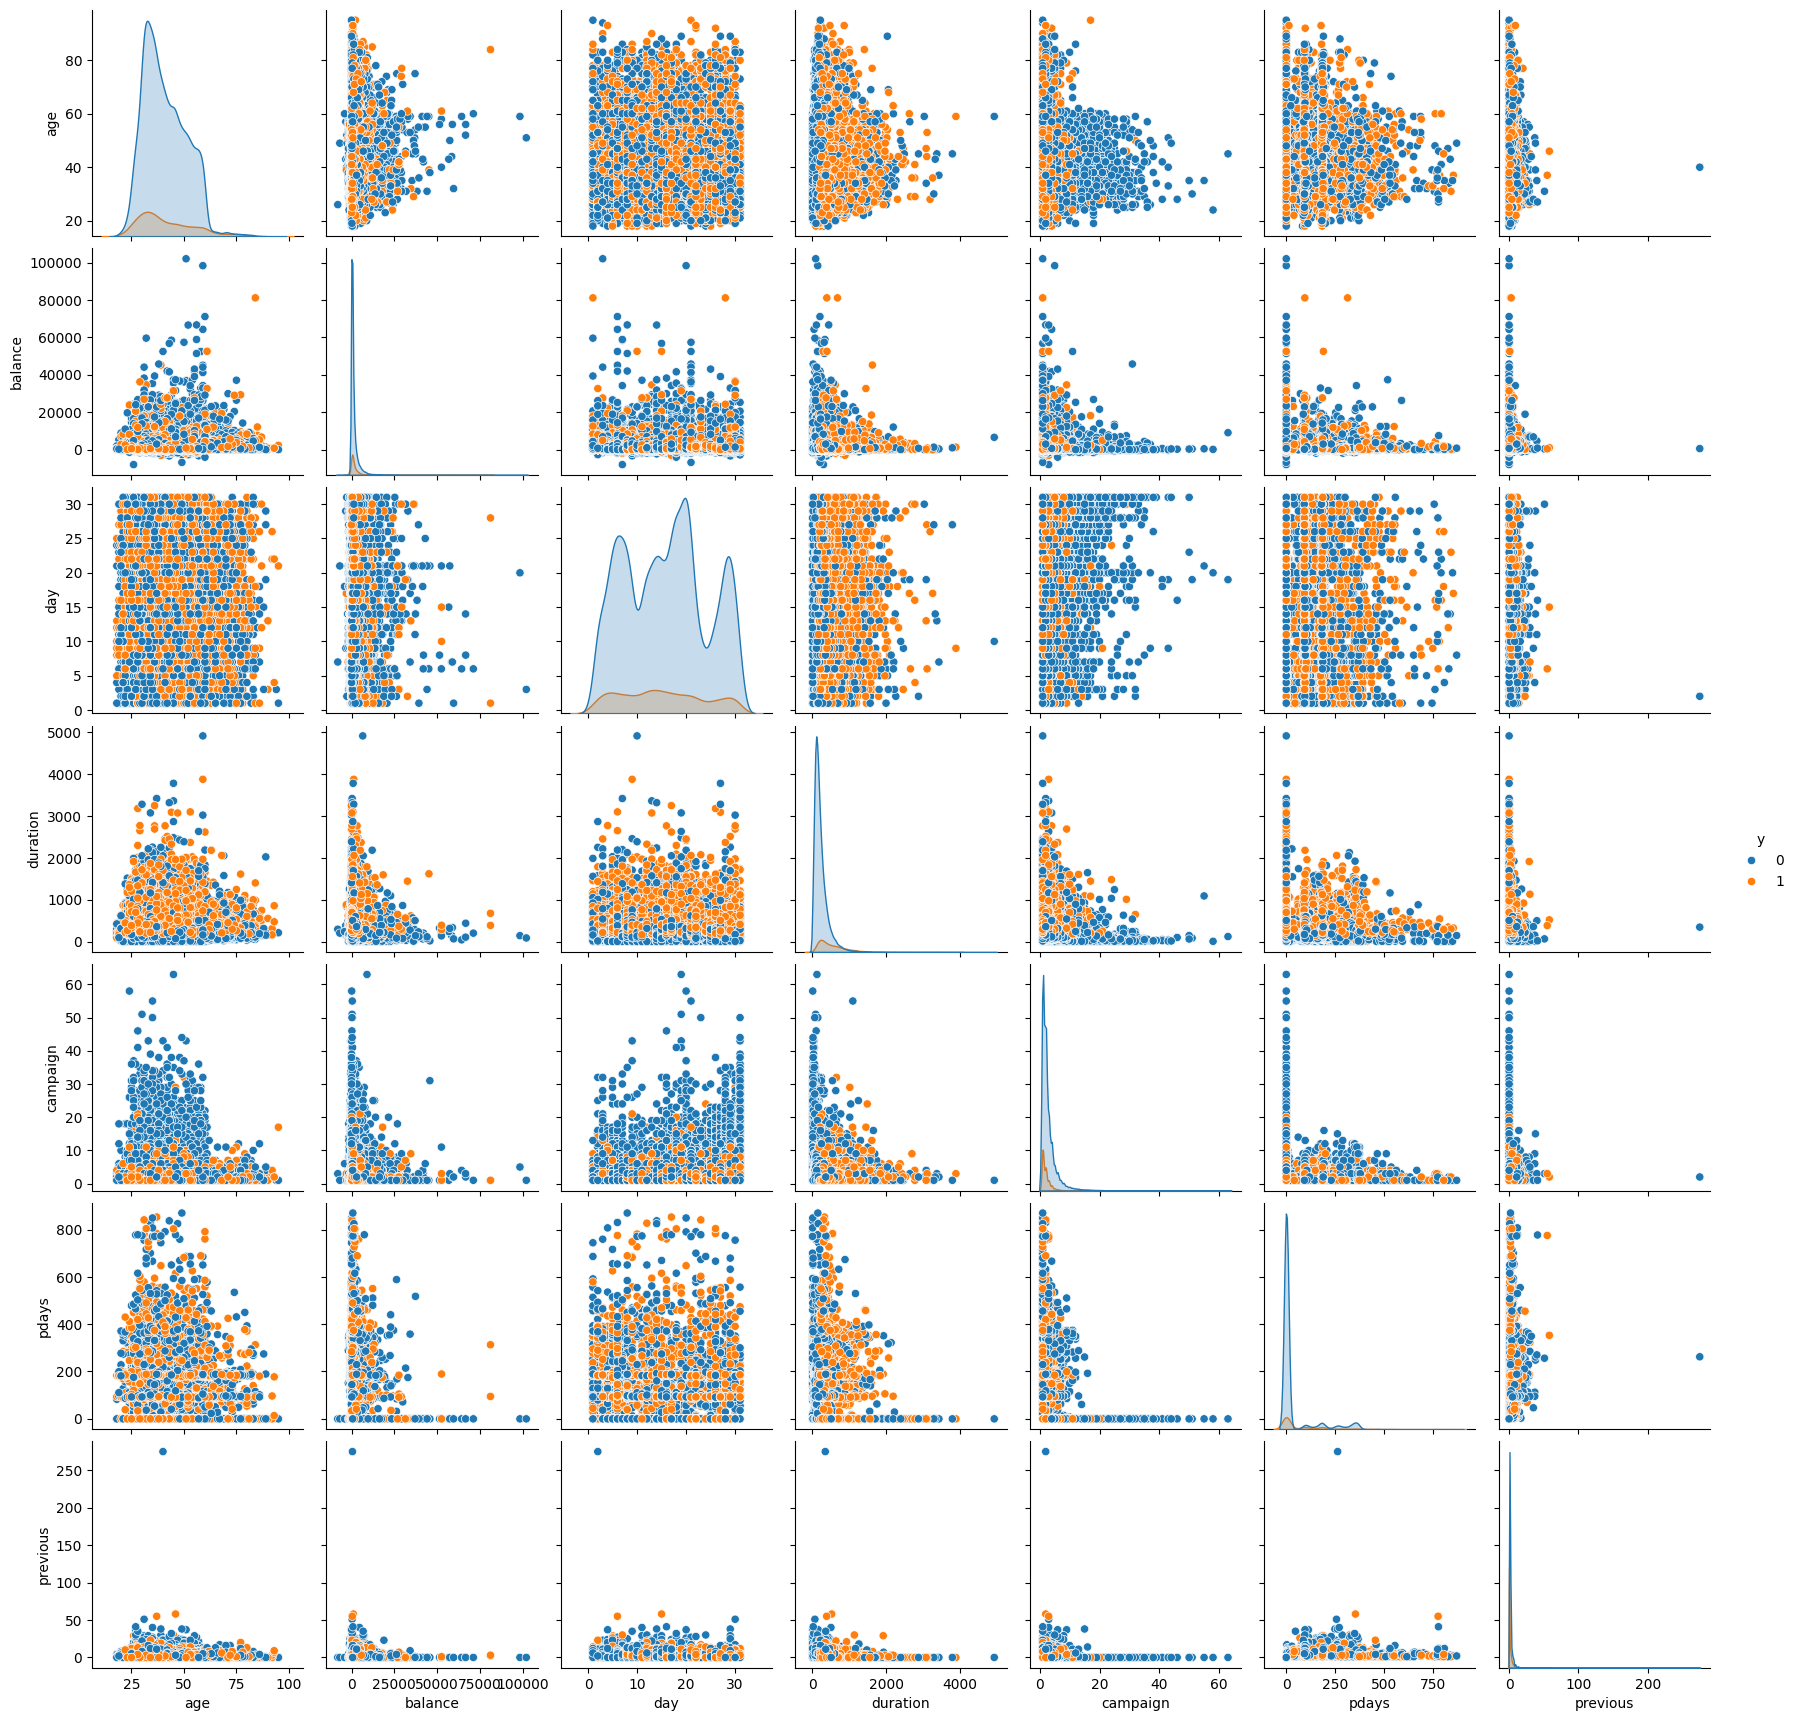

In [27]:
sns.pairplot(dfauxNUM.toPandas(), kind='scatter', hue='y')
plt.show()

#### Comentarios:
- **Duration y Y:**
  Los clientes que aceptaron el depósito tienden a tener llamadas más largas.
  Los valores “yes” aparecen más dispersos en duraciones altas.
  
- **Campaign:**
  Se observa que muchos clientes fueron contactados pocas veces.
  A medida que aumenta el número de contactos en campaña, disminuyen los casos positivos.

  
- **Balance:**
  Existen valores extremos altos (outliers).

  
- **Age:**
  La edad individualmente no parece tener una fuerte influencia lineal sobre la suscripción.

#### **Conclusiones Generales:**
A partir del análisis posteriores se pueden extraer las siguientes conclusiones:
- DURATION es la variable numérica más relevante para predecir la suscripción al depósito a plazo fijo.
- Existe multicolinealidad moderada entre PDAYS y PREVIOUS, por lo que eliminar PDAYS es una decisión adecuada.
- Variables como CAMPAIGN muestran posibles patrones importantes, demasiados contactos podrían disminuir la efectividad de la campaña.
- Aunque algunas correlaciones son bajas, esto no significa que las variables sean inútiles; modelos más complejos pueden capturar relaciones no lineales.
- Todos las análisis posteriores permiten identificar variables relevantes y posibles problemas antes de construir modelos predictivos.

### Gráfica de Torta para varibles Binarias "yes" "no"
Las gráficas de torta o gráficas circulares se utilizan para representar la proporción o porcentaje que aporta cada categoría respecto al total de los datos.
Cada porción de la torta representa una categoría y su tamaño depende de la frecuencia o porcentaje que tenga dentro del conjunto de datos.
Son funcionales para  mostrar porcentaes, comparar proporcionesy  facilitar la interpretación visual
- Housing.
- Default.
- Loan.

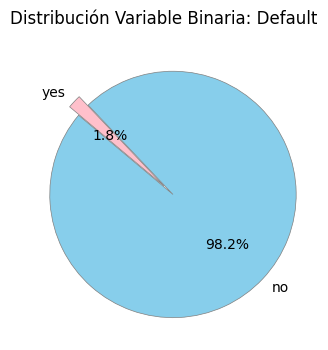

In [28]:
### Se requiere pintar ['default', 'housing', 'loan] por separado
### De esa manera se hace puntual analísis
explode = (0.1,0)
colors =['skyblue', 'pink']

plt.figure(figsize=(5,4))
cantBin = dfPy01.groupBy('default').count().toPandas()
cantBin.set_index('default')['count'].plot(kind='pie', explode=explode, colors=colors, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'gray','linewidth':0.5})
plt.title(f'Distribución Variable Binaria: Default')
plt.ylabel('')
plt.show()
plt.show()



#### Comentarios Gráfica #1: **Default**
- El 98.2% de los clientes no presenta créditos en mora.
- Solo el 1.8% de los clientes tiene historial de incumplimiento de pagos.
- La mayoría de los clientes del banco poseen estabilidad financiera respecto a sus obligaciones crediticias, lo cual puede influir positivamente en campañas relacionadas con productos financieros.

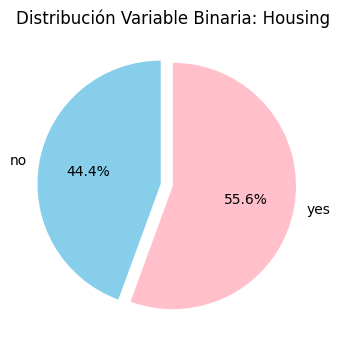

In [29]:
explode = (0.1,0)
colors =['skyblue', 'pink']

plt.figure(figsize=(5,4))
cantBin = dfPy01.groupBy('housing').count().toPandas()
cantBin.set_index('housing')['count'].plot(kind='pie', explode=explode, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title(f'Distribución Variable Binaria: Housing')
plt.ylabel('')
plt.show()
plt.show()

#### Comentarios Gráfica #2: **Housing**
- El 55.6% de los clientes sí posee préstamo hipotecario.
- El 44.4% no tiene este tipo de préstamo.
- Existe una ligera mayoría de clientes con créditos hipotecarios, lo cual sugiere que el banco tiene una fuerte participación en productos relacionados con vivienda.

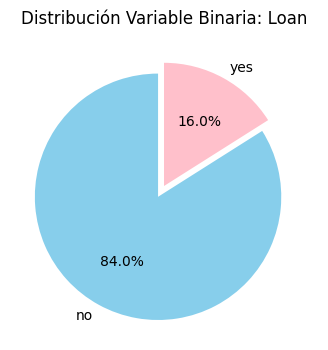

In [30]:
explode = (0.1,0)
colors =['skyblue', 'pink']

plt.figure(figsize=(5,4))
cantBin = dfPy01.groupBy('loan').count().toPandas()
cantBin.set_index('loan')['count'].plot(kind='pie', explode=explode, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title(f'Distribución Variable Binaria: Loan')
plt.ylabel('')
plt.show()
plt.show()

#### Comentarios Gráfica #3: **Loan**
- El 84.0% de los clientes no tiene préstamos personales.
- Solo el 16.0% sí posee este tipo de préstamo.
- Los préstamos personales no son predominantes entre los clientes analizados, por lo que este producto financiero parece tener menor alcance en comparación con los préstamos hipotecarios.

### **Conclusión General**
- El análisis de las variables binarias permite identificar patrones importantes en el comportamiento financiero de los clientes:
- DEFAULT muestra una población con bajo nivel de morosidad.
- HOUSING presenta una distribución equilibrada, indicando una participación significativa en créditos hipotecarios.
- LOAN evidencia que los préstamos personales son menos frecuentes.

### Variables Categóricas Multidimensión

<Figure size 800x600 with 0 Axes>

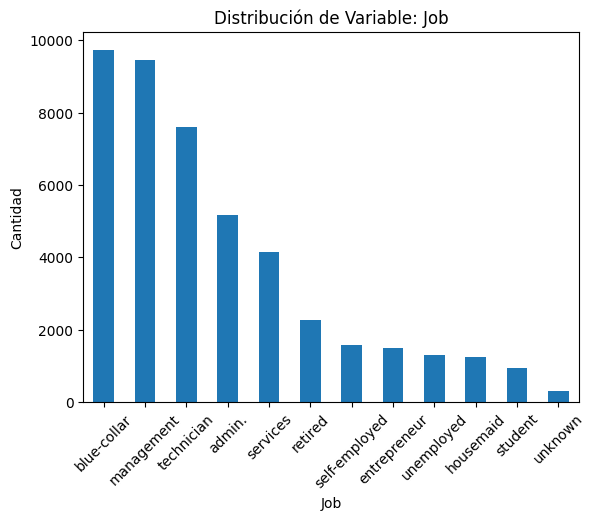

In [31]:
## Las variables son : ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
cantMulti = dfPy01.groupBy('job').count().toPandas()
###--> Se gráfica con orden ascendente según frecuencia
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
cantMulti.plot(kind='bar', x='job', y='count', legend=None)
plt.xlabel('Job')
plt.ylabel('Cantidad')
plt.title(f'Distribución de Variable: Job')
plt.xticks(rotation=45)
plt.show()

#### Análisis - Distribución de la variable trabajo:
- Se observa que los empleados de obreros (blue-collar), gestión/administración (management)
técnicos (technician), son los que mayor cantidad de registros tienen.
- Las categorías menos frecuentes son, estudiantes (student), desconocido (unknown) y retirado(a) (retired).

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 800x600 with 0 Axes>

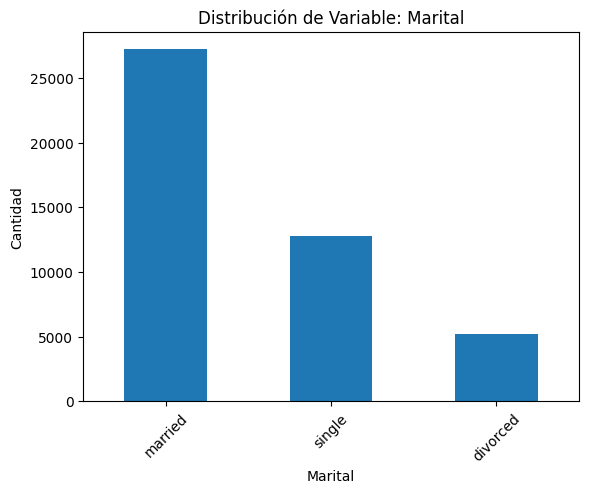

In [32]:
cantMulti = dfPy01.groupBy('marital').count().toPandas()
###--> Se gráfica con orden ascendente según frecuencia
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
cantMulti.plot(kind='bar', x='marital', y='count', legend=None)
plt.xlabel('Marital')
plt.ylabel('Cantidad')
plt.title(f'Distribución de Variable: Marital')
plt.xticks(rotation=45)
plt.show

#### Análisis - Distribición del Estado Cívil:
- La distribución muestra tres categorías principales: casado(a) (married); categoría dominante, soltero(a) (single) y divorciado/viudo (divorced).
- La mayoría de los clientes están casados.
- Los clientes solteros representan aproximadamente la mitad de los casados.
- Los divorciados constituyen la menor proporción.

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 800x600 with 0 Axes>

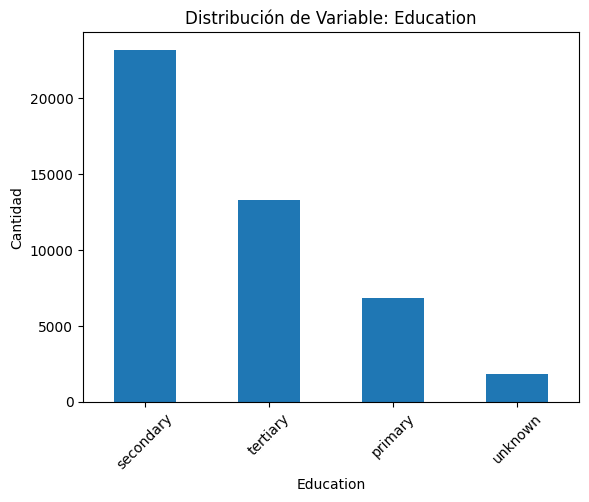

In [33]:
cantMulti = dfPy01.groupBy('education').count().toPandas()
###--> Se gráfica con orden ascendente según frecuencia
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
cantMulti.plot(kind='bar', x='education', y='count', legend=None)
plt.xlabel('Education')
plt.ylabel('Cantidad')
plt.title(f'Distribución de Variable: Education')
plt.xticks(rotation=45)
plt.show

#### Análisis - Distribución del Nivel Educativo:
- La gráfica evidencia cuatro categorías principales:secundaria (secondary); mayor frecuencia, educación superior/universitaria (tertiary), primaria (primary) y desconocido (unknown).
- La mayoría de clientes posee educación secundaria.
- Un grupo considerable tiene educación terciaria.
- Los niveles primarios y desconocidos son minoritarios.

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 800x600 with 0 Axes>

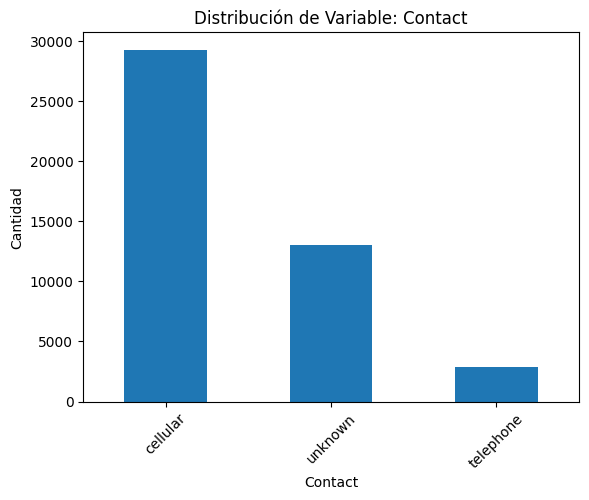

In [34]:
cantMulti = dfPy01.groupBy('contact').count().toPandas()
###--> Se gráfica con orden ascendente según frecuencia
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
cantMulti.plot(kind='bar', x='contact', y='count', legend=None)
plt.xlabel('Contact')
plt.ylabel('Cantidad')
plt.title(f'Distribución de Variable: Contact')
plt.xticks(rotation=45)
plt.show

#### Análisis - Distribución del tipo de comunicación:
- cellular → contacto mediante teléfono celular / telephone → contacto mediante teléfono fijo / unknown → medio de contacto desconocido.
- La mayoría de los contactos se realizaron por celular, con aproximadamente 29 mil registros.
- La categoría unknown ocupa el segundo lugar con cerca de 13 mil registros.
- El contacto por telephone es considerablemente menor, con alrededor de 3 mil registros.
- La presencia de muchos valores unknown indica datos faltantes o información no registrada, lo cual es importante considerar.

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 800x600 with 0 Axes>

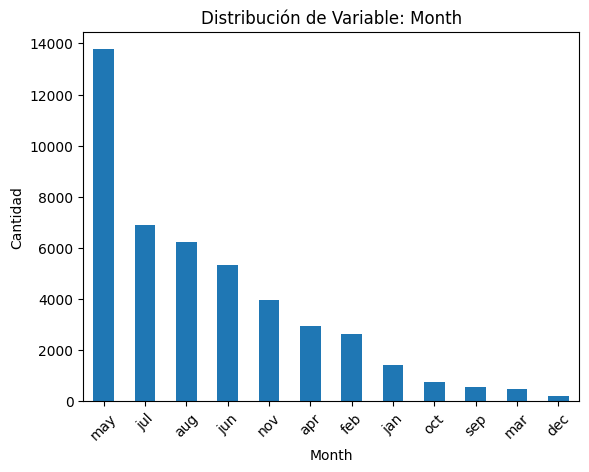

In [35]:
cantMulti = dfPy01.groupBy('month').count().toPandas()
###--> Se gráfica con orden ascendente según frecuencia
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
cantMulti.plot(kind='bar', x='month', y='count', legend=None)
plt.xlabel('Month')
plt.ylabel('Cantidad')
plt.title(f'Distribución de Variable: Month')
plt.xticks(rotation=45)
plt.show

#### Análisis - Distribución de los meses:
- El mes con mayor cantidad de contactos es mayo (may), con aproximadamente 14 mil registros.
- Los meses con menor cantidad de contactos son: Diciembre (dec), Marzo (mar), Septiempre (sep) y Octubre (oct).
- La campaña de marketing se concentró principalmente entre mayo y agosto, lo que podría indicar, temporadas estratégicas de captación,mayor disponibilidad de clientes o mejores tasas de respuesta en esos meses.
- La baja actividad en diciembre puede relacionarse con, el cierre de actividades comerciales,
vacaciones o menor efectividad de campañas en esa temporada.

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 800x600 with 0 Axes>

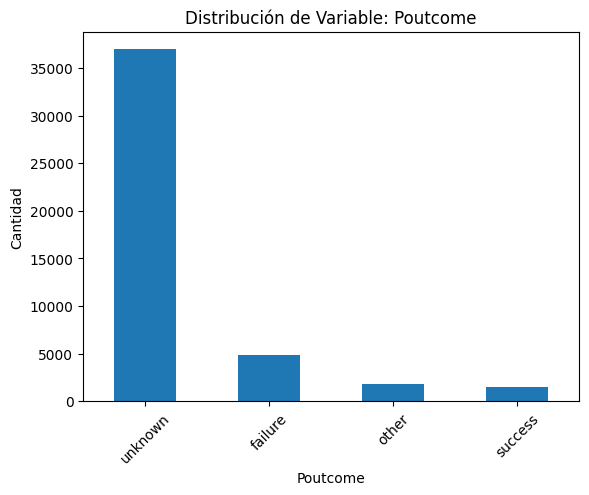

In [36]:
cantMulti = dfPy01.groupBy('poutcome').count().toPandas()
###--> Se gráfica con orden ascendente según frecuencia
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
cantMulti.plot(kind='bar', x='poutcome', y='count', legend=None)
plt.xlabel('Poutcome')
plt.ylabel('Cantidad')
plt.title(f'Distribución de Variable: Poutcome')
plt.xticks(rotation=45)
plt.show

#### Análisis - Distribución de las campañas de marketing anteriores:
- La categoría dominante es (unknown) no existe información o no hubo campaña previa, con aproximadamente 37 mil registros.
- Los casos de campañas anteriores fallidas (failure) son mucho menores.
- mientras que campaña anterior exitosa (success) y otro resultado (other) tienen muy poca representación.

## Graficos de barras agrupados por variables categóricas en relación a la variable dependiente "y" (Depósito a Plazo fijo)

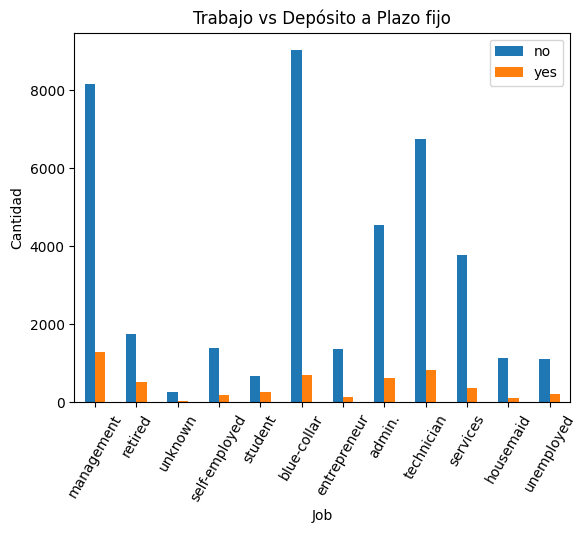

In [37]:
### Seleccionar sólo las variables categóricas
### col_cat= ['job', 'marital', 'eduation', 'default', 'housing', 'loan', 'contact','month', 'poutcome', 'y']
cratabJob = dfPy01.crosstab('job','y').toPandas()
cratabJob.set_index('job' + '_y').plot(kind='bar')
plt.xlabel('Job')
plt.ylabel('Cantidad')
plt.title('Trabajo vs Depósito a Plazo fijo') #Job vs variable dependiente Depósito:y
plt.xticks(rotation=60)
plt.show()

#### Análisis - Trabajo Vs Depósito a plazo fijo:
- En todos los trabajos predominan las respuestas “no”, lo que indica que la mayoría de clientes no aceptó el depósito a plazo fijo.
- Los clientes cuya ocupación es de estudiante o retirado presentan proporcionalmente una mayor cantidad de respuestas “yes” respecto a su tamaño poblacional.
- La ocupación sí parece influir en la aceptación del depósito.

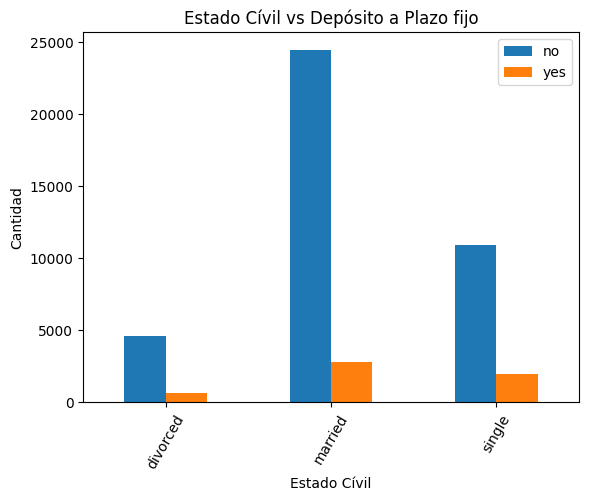

In [38]:
cratabJob = dfPy01.crosstab('marital','y').toPandas()
cratabJob.set_index('marital' + '_y').plot(kind='bar')
plt.xlabel('Estado Cívil')
plt.ylabel('Cantidad')
plt.title('Estado Cívil vs Depósito a Plazo fijo') #marital vs variable dependiente Depósito:y
plt.xticks(rotation=60)
plt.show()

#### Análisis - Estado Cívil Vs Depósito a plazo fijo:
- Aunque los casados tienen más respuestas “yes” en cantidad absoluta, también son el grupo más numeroso.
- Proporcionalmente, los clientes solteros parecen tener una mejor aceptación.

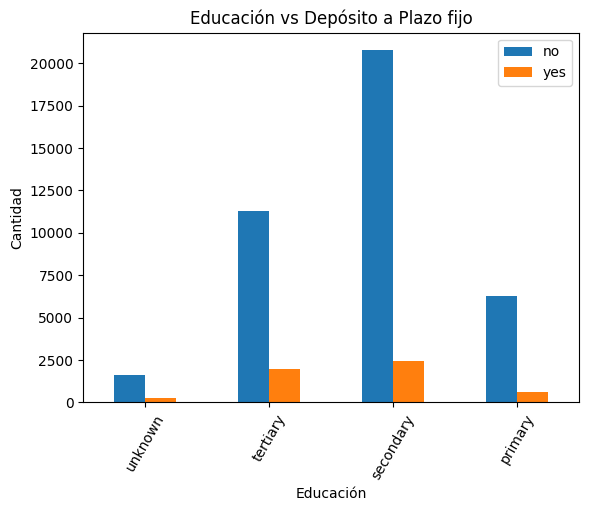

In [39]:
cratabJob = dfPy01.crosstab('education','y').toPandas()
cratabJob.set_index('education' + '_y').plot(kind='bar')
plt.xlabel('Educación')
plt.ylabel('Cantidad')
plt.title('Educación vs Depósito a Plazo fijo') #education vs variable dependiente Depósito:y
plt.xticks(rotation=60)
plt.show()

#### Análisis - Nivel Educativo Vs Depósito a Plazo fijo:
- Los clientes con educación tertiary presentan una cantidad considerable de respuestas “yes”.
- Los clientes con educación primaria muestran menor aceptación proporcional.
- La mayor cantidad de clientes pertenece al nivel de educación secundaria (secondary).

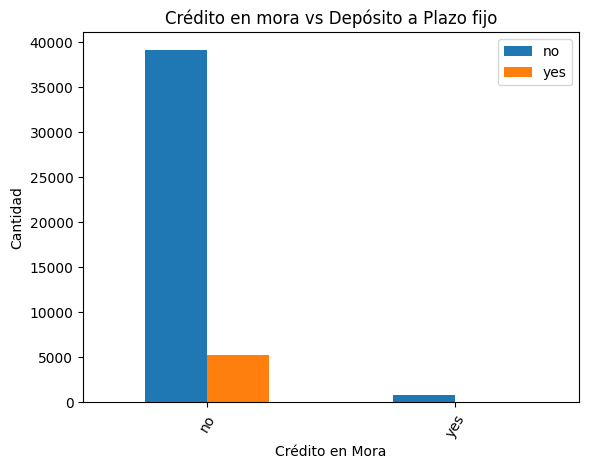

In [40]:
cratabJob = dfPy01.crosstab('default','y').toPandas()
cratabJob.set_index('default' + '_y').plot(kind='bar')
plt.xlabel('Crédito en Mora')
plt.ylabel('Cantidad')
plt.title('Crédito en mora vs Depósito a Plazo fijo') #default vs variable dependiente Depósito:y
plt.xticks(rotation=60)
plt.show()

#### Análisis - Crédito en Mora Vs Depósito a PLazo fijo:
- Se observa que la categoría “no” tiene una cantidad extremadamente superior de registros frente a la categoría “yes”. Lo que indica que la mayoría de clientes del banco poseen un buen comportamiento crediticio.
- Los clientes con mora casi no adquieren depósitos.
- Los clientes sin mora son quienes más adquieren depósitos a plazo fijo.

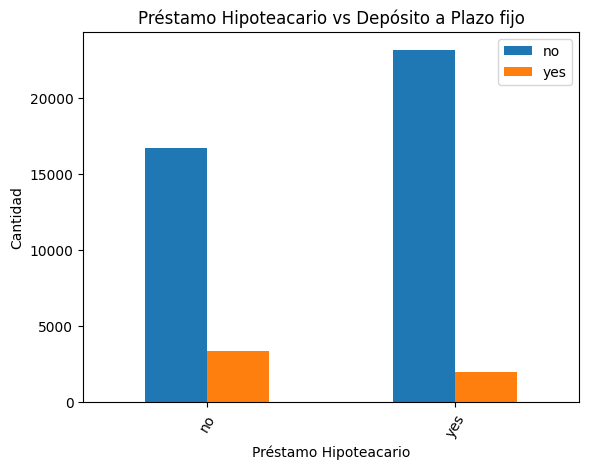

In [41]:
cratabJob = dfPy01.crosstab('housing','y').toPandas()
cratabJob.set_index('housing' + '_y').plot(kind='bar')
plt.xlabel('Préstamo Hipoteacario')
plt.ylabel('Cantidad')
plt.title('Préstamo Hipoteacario vs Depósito a Plazo fijo') #housing vs variable dependiente Depósito:y
plt.xticks(rotation=60)
plt.show()

#### Análisis - Préstamo Hipotecario Vs Depósito a Plazo Fijo:
- La gráfica muestra que existe una gran cantidad de clientes que poseen préstamo hipotecario. Esto indica que muchos clientes mantienen compromisos financieros relacionados con vivienda.
- Los clientes sin préstamo hipotecario tienen una mayor cantidad de suscripciones al depósito.
- Los clientes con hipoteca presentan menos aceptación proporcionalmente.

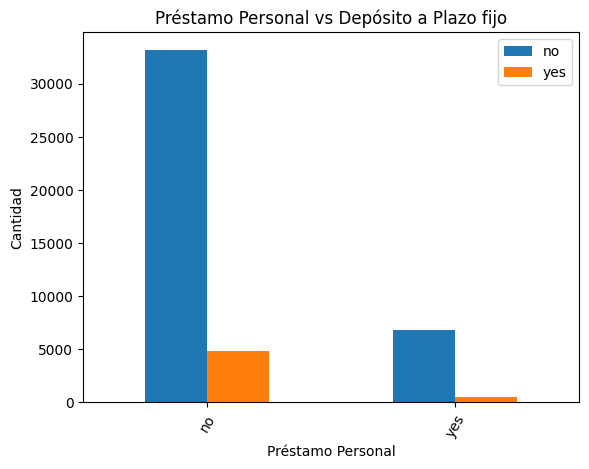

In [42]:
cratabJob = dfPy01.crosstab('loan','y').toPandas()
cratabJob.set_index('loan' + '_y').plot(kind='bar')
plt.xlabel('Préstamo Personal')
plt.ylabel('Cantidad')
plt.title('Préstamo Personal vs Depósito a Plazo fijo') #loan vs variable dependiente Depósito:y
plt.xticks(rotation=60)
plt.show()

#### Análisis - Préstamo Personal Vs Depósito a Plazo Fijo:
- La mayoría de clientes no tiene préstamo personal.
- Los clientes sin préstamo personal son quienes más se suscriben.
- Los clientes con préstamo personal presentan baja participación a la subcripción del depósito a plazo fijo.

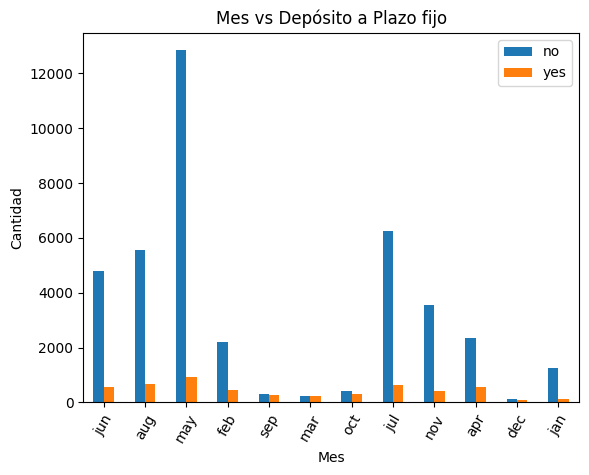

In [43]:
cratabJob = dfPy01.crosstab('month','y').toPandas()
cratabJob.set_index('month' + '_y').plot(kind='bar')
plt.xlabel('Mes')
plt.ylabel('Cantidad')
plt.title('Mes vs Depósito a Plazo fijo') #month vs variable dependiente Depósito:y
plt.xticks(rotation=60)
plt.show()

#### Análisis - Mes Vs Depósito a Plazo Fijo:
- El mes de mayo (may) presenta la mayor cantidad de contactos realizados por el banco.
- Sin embargo, aunque mayo tiene muchos contactos, también posee una gran cantidad de respuestas negativas (no).
- Los meses de julio (jul), agosto (aug) y junio (jun) también muestran altos volúmenes de clientes contactados.
- En meses como marzo (mar), septiembre (sep) y diciembre (dec) el número de contactos es considerablemente menor.

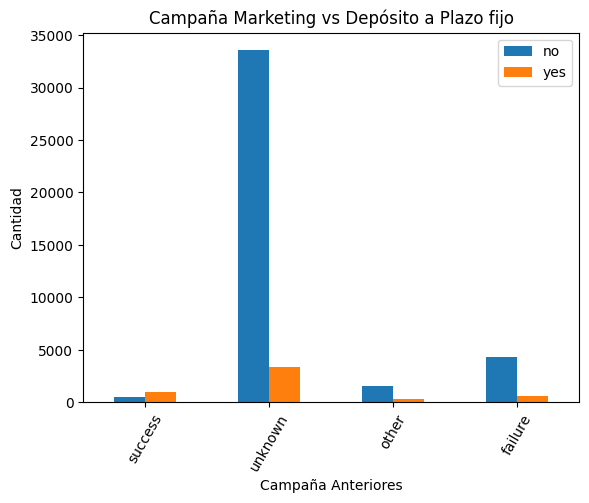

In [44]:
cratabJob = dfPy01.crosstab('poutcome','y').toPandas()
cratabJob.set_index('poutcome' + '_y').plot(kind='bar')
plt.xlabel('Campaña Anteriores')
plt.ylabel('Cantidad')
plt.title('Campaña Marketing vs Depósito a Plazo fijo') #poutcome vs variable dependiente Depósito:y
plt.xticks(rotation=60)
plt.show()

#### Análisis - Campaña Anteriores Vs Depósito a Plazo Fijo:
- La categoría unknown domina claramente el dataset, lo que infiere que muchos clientes no habían sido contactados antes o no se tiene registro del resultado.
- Cuando la campaña anterior fue exitosa (success), la cantidad de clientes que aceptan el depósito (yes) es proporcionalmente alta.
- En campañas anteriores fallidas (failure), predominan las respuestas negativas (no).

## **Comparativa entre las variables Numéricas y las Categóricas**

In [45]:
dfPy01.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

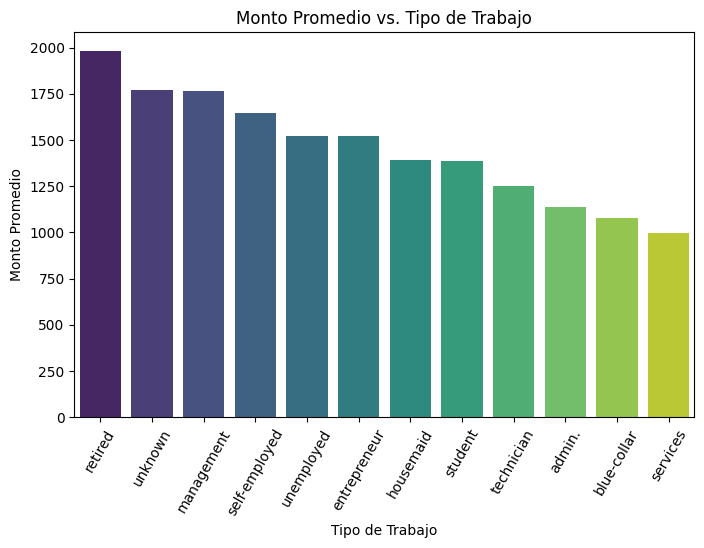

In [46]:
## Lista personal sobre el nombre de las variables
nomColumnas = ['age', 'job','marital','education','default','balance','housing','loan','contact','day','month','duration','campaign','pdays','previous','poutcome','y']
### Las siguientes columnas son Numéricas
colNum = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

### Se requiere graficar la relación del balance (monto promedio anual) por categoria de Job (tipo de trabajo)
monto_trabajo = dfPy01.groupBy('job').agg({'balance':'mean'}).toPandas()
### El promedio sobre el monto y el tipo de trabajo: Se ordena de mayor a menor por monto
monto_trabajo = monto_trabajo.sort_values('avg(balance)', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=monto_trabajo, x='job', y='avg(balance)', palette='viridis', hue='job')
plt.xlabel("Tipo de Trabajo")
plt.ylabel("Monto Promedio")
plt.title("Monto Promedio vs. Tipo de Trabajo")
plt.xticks(rotation=60)
plt.show()

#### Comentarios:
- Los clientes jubilados (retired) presentan el mayor monto promedio, cercano a los 2000 euros.
- La categoría unknown también presenta un balance elevado, así como también management, self-employed y entrepreneur.
- Los grupos con menor saldo promedio son: services, blue-collar y admin.
- La ocupación del cliente influye en su capacidad financiera y posiblemente en su disposición para invertir en depósitos a plazo fijo.
- El tipo de trabajo influye en el saldo promedio de los clientes. Los perfiles laborales con mayor estabilidad o ingresos presentan balances más altos, mientras que ocupaciones de menor ingreso tienen balances promedio más bajos. Esta relación puede ser útil para segmentación de clientes y para modelos predictivos relacionados con productos financieros.

### **4. Verificación de la calidad de los Datos.**
- Verificación la cantidad de datos nulos

In [47]:
for columna in dfPy01.columns:
    cantNulos = dfPy01.where(F.col(columna).isNull()).count()
    print(f"'{columna}' : {cantNulos} valores nulos")

'age' : 0 valores nulos
'job' : 0 valores nulos
'marital' : 0 valores nulos
'education' : 0 valores nulos
'default' : 0 valores nulos
'balance' : 0 valores nulos
'housing' : 0 valores nulos
'loan' : 0 valores nulos
'contact' : 0 valores nulos
'day' : 0 valores nulos
'month' : 0 valores nulos
'duration' : 0 valores nulos
'campaign' : 0 valores nulos
'pdays' : 0 valores nulos
'previous' : 0 valores nulos
'poutcome' : 0 valores nulos
'y' : 0 valores nulos


#### **Comentarios:**
- Dentro del dataset se verificó que no existen datos faltantes o nulos, lo cual es positivo.

### **5. Preparación de los Datos.**
    - pdays: Número de días transcurridos desde el último contacto en una campaña previa (-1 indica que no fue contactado anteriormente).
    - Previous: Número de contactos realizados antes de esta campaña para este cliente.

In [48]:
### Cantidad de días que han pasado desde que el cliente fue contactado
# Se requiere saber la cantidad de -1 pdays (cliente no fue previamente contactado)
noPDAYS = dfPy01.filter(F.col('pdays') == -1).count()
# Porcentaje
porcNoPDAYS = (noPDAYS/total)*100
print(f"Porcentaje de clientes no contactados con anterioridad (variable PDAYS = -1): {porcNoPDAYS:.2f}%")

Porcentaje de clientes no contactados con anterioridad (variable PDAYS = -1): 81.74%


#### **Comentarios**
    - Porcentaje de PDAYS muy alto.
    - La correlación con PREVIUS es de 0.45 (fuerte relación).
    - Se recomienda descartar la variable por el 82% de frecuencia y la alta relación con la variable Previous.
    - Para la preparación del actual investigación se descarta la variable 'PDAYS'.

In [49]:
### lA IDEA es revisar el valor límite de número de contactos realizado por clientes
### Se presenta la cantidad de contactos realizados en orden descendiente
dfPy01.groupBy("previous").count().sort("previous", ascending=False).show()

+--------+-----+
|previous|count|
+--------+-----+
|     275|    1|
|      58|    1|
|      55|    1|
|      51|    1|
|      41|    1|
|      40|    1|
|      38|    2|
|      37|    2|
|      35|    1|
|      32|    1|
|      30|    3|
|      29|    4|
|      28|    2|
|      27|    5|
|      26|    2|
|      25|    4|
|      24|    5|
|      23|    8|
|      22|    6|
|      21|    4|
+--------+-----+
only showing top 20 rows



#### Comentarios:
- Se mostraron el número de veces que el cliente fue contactado antes de la campaña actual.
- Existen valores muy altos pero poco frecuente como, 275, 58, 55, etc...
- Puede existir la presencia de outliers y una fuerte asimetría. La mayoría de los clientes probablemente tuvo pocos contactos previos, mientras que algunos casos específicos registran una gran cantidad de interacciones anteriores.
- Esta variable puede ser relevante para analizar el comportamiento histórico del cliente y su relación con la aceptación de productos financieros.

In [50]:
## se toma como valor máximo 30 contactos por cliente y los demás atípicos
limitePrevio = 30
## Cantidad de registros con contactos "numeroContactos" superiores al limite
cantPrevioLim = dfPy01.filter(F.col('previous') > limitePrevio).count()
print(f"Cantidad de registros superiores a {limitePrevio} contactos realizado: {cantPrevioLim}")

Cantidad de registros superiores a 30 contactos realizado: 12


#### **Análisis**

- Tras analizar los datos, se observa que, de los que tienen más de 30 contactos, solo con 12 clientes, lo que supone un caso atípico.

- Se recomienda eliminar los 12 registros.

### **6. Limpieza de los Datos.**

In [51]:
## Se eliminan los datos de la variable "previous" con más de 30 contactos
df02 = dfPy01.filter(F.col('previous')<=30)

In [52]:
## Se elimina la columna "pdays"
df03 = df02.drop('pdays')

### **7. Formato de los Datos.**
    - Balanceo de aparición de la variable dependiente en los datos.
    - La idea es evitar el skew (sesgo) para la clase de mayor aparición ("no").

In [53]:
## Balanceo de variable dependiente:
dfMayorDependiente = df03.filter(df03['y'] == 'no')
dfMenorDependiente = df03.filter(df03['y'] == 'yes')

## Cantidad de clase mayoritaria (y)
cantMayor = dfMayorDependiente.count()

## Se realiza el oversampling sobre la clase minoritaria de la variable dependiente
dfOverSampledMinor = dfMenorDependiente.sample(True, cantMayor/dfMenorDependiente.count(), seed=42)

##Se combina los dataframes
df04 = dfMayorDependiente.union(dfOverSampledMinor)

In [54]:
print(f"El df04 queda (luego del oversampling) = {df04.count()}")

El df04 queda (luego del oversampling) = 80201


In [55]:
df04.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'previous',
 'poutcome',
 'y']

In [56]:
## Se presenta el porcentaje según el balanceo aplicado

totalNw =df04.count()

dfaux = df04.groupBy('y').count()

dfBalance = dfaux.withColumn("Porcentaje", dfaux["count"]*100/totalNw)
dfBalance.show()

+---+-----+-----------------+
|  y|count|       Porcentaje|
+---+-----+-----------------+
| no|39912|49.76496552412065|
|yes|40289|50.23503447587935|
+---+-----+-----------------+



In [57]:
print(f"Cantidad de registros de DF01 = {dfPy01.count()}")
print(f"Cantidad de registros de DF04 = {df04.count()}")

Cantidad de registros de DF01 = 45211
Cantidad de registros de DF04 = 80201


### **8. Codificación para la creación de vector ensamblador para las variables categóticas ("features", "target")**
    - Debemos tener claras las categorías para 

In [58]:
## Columnas categoricas

CATEG_col = ['job', 'marital', 'education', 'default', 'month', 'housing','loan','contact', 'poutcome']

##vector de pipeline

etapas = []

for colCategorie in CATEG_col:
    #Se identifica el nombre de la categoría según aparición
    indexer = StringIndexer(inputCol=colCategorie, outputCol=colCategorie + 'x')
    #Se decodifica el indice de la categoria
    encoder = OneHotEncoder(inputCols=[indexer.getOutputCol()], outputCols=[colCategorie + '_oneHot'])
    etapas += [indexer, encoder]

In [59]:
etapas

[StringIndexer_027073cba064,
 OneHotEncoder_5ea836230605,
 StringIndexer_046a955a6344,
 OneHotEncoder_dee6db395e6f,
 StringIndexer_4d723676c317,
 OneHotEncoder_6dba7c12d4cf,
 StringIndexer_40b0f278d0b9,
 OneHotEncoder_332b81548e63,
 StringIndexer_9b3cb6728e4b,
 OneHotEncoder_d73bc2edf53b,
 StringIndexer_8f22f088955e,
 OneHotEncoder_d43fb03147b2,
 StringIndexer_f4462e4e00b8,
 OneHotEncoder_e70f85212088,
 StringIndexer_89598571c8cf,
 OneHotEncoder_1ec6f02184b2,
 StringIndexer_3bb0775a778d,
 OneHotEncoder_e6a370d10657]

In [60]:
# Creación del StringIndexer con el orden deseado
# Al utilizar stringOrderType="alphabet", se indica que se asigne el índice 0 a «no» y el índice 1 a «yes» según el orden alfabético
etiqueta = StringIndexer(inputCol='y', outputCol='label', stringOrderType='alphabetAsc')
etapas += [etiqueta]

In [61]:
NUMBER_col = ['age', 'balance', 'duration', 'day', 'campaign', 'previous']
entradaEnsamblada = [c + '_oneHot' for c in CATEG_col] + NUMBER_col
entradaEnsamblada

['job_oneHot',
 'marital_oneHot',
 'education_oneHot',
 'default_oneHot',
 'month_oneHot',
 'housing_oneHot',
 'loan_oneHot',
 'contact_oneHot',
 'poutcome_oneHot',
 'age',
 'balance',
 'duration',
 'day',
 'campaign',
 'previous']

In [62]:
### Tabla de características del vector para entrenamiento de los modelos
VectorEnsamblado = VectorAssembler(inputCols= entradaEnsamblada, outputCol='features')
etapas += [VectorEnsamblado]

In [63]:
etapas

[StringIndexer_027073cba064,
 OneHotEncoder_5ea836230605,
 StringIndexer_046a955a6344,
 OneHotEncoder_dee6db395e6f,
 StringIndexer_4d723676c317,
 OneHotEncoder_6dba7c12d4cf,
 StringIndexer_40b0f278d0b9,
 OneHotEncoder_332b81548e63,
 StringIndexer_9b3cb6728e4b,
 OneHotEncoder_d73bc2edf53b,
 StringIndexer_8f22f088955e,
 OneHotEncoder_d43fb03147b2,
 StringIndexer_f4462e4e00b8,
 OneHotEncoder_e70f85212088,
 StringIndexer_89598571c8cf,
 OneHotEncoder_1ec6f02184b2,
 StringIndexer_3bb0775a778d,
 OneHotEncoder_e6a370d10657,
 StringIndexer_1f57dfdf1f07,
 VectorAssembler_814269b47843]

In [64]:
### Pipeline para Streaming: ejecución de la transformación del onehotencoder a el vector ensamblado 'features'

pipeline = Pipeline(stages=etapas)
pipelineModel = pipeline.fit(df04)
## Se almacena
pipelineModel.write().overwrite().save(path='modeloPipeline')
modelo = pipelineModel.transform(df04)

In [65]:
modelo.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)
 |-- jobx: double (nullable = false)
 |-- job_oneHot: vector (nullable = true)
 |-- maritalx: double (nullable = false)
 |-- marital_oneHot: vector (nullable = true)
 |-- educationx: double (nullable = false)
 |-- education_oneHot: vector (nullable = true)
 |-- defaultx: double (nullable = false)
 |-- default_oneHot: vector (nullable = true)
 |-- monthx: double (nullable = false)

In [66]:
modelo.show(5)

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+--------+--------+---+----+--------------+--------+--------------+----------+----------------+--------+--------------+------+--------------+--------+--------------+-----+-------------+--------+--------------+---------+---------------+-----+--------------------+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|previous|poutcome|  y|jobx|    job_oneHot|maritalx|marital_oneHot|educationx|education_oneHot|defaultx|default_oneHot|monthx|  month_oneHot|housingx|housing_oneHot|loanx|  loan_oneHot|contactx|contact_oneHot|poutcomex|poutcome_oneHot|label|            features|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+--------+--------+---+----+--------------+--------+--------------+----------+----------------+--------+--------------+------+--------------+--------+--------------+-----+---

In [67]:
## Se crea el Dataframe final para los modelos
df05 = modelo.select("label", "features")

### Se imprime el primer registro para hacer inspección ocular
df05.first()

Row(label=0.0, features=SparseVector(41, {0: 1.0, 11: 1.0, 14: 1.0, 16: 1.0, 17: 1.0, 29: 1.0, 31: 1.0, 32: 1.0, 35: 58.0, 36: 2143.0, 37: 261.0, 38: 5.0, 39: 1.0}))

In [68]:
df05.printSchema()

root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)



In [69]:
# Parquet preserves SparseVector structure efficientrly
df05.write.mode("overwrite").parquet("output.parquet")

In [70]:
# To read back later
df07 = sparkGomez.read.parquet("output.parquet")
df07.show(2)

AnalysisException: [UNABLE_TO_INFER_SCHEMA] Unable to infer schema for Parquet. It must be specified manually.

### **9. Modelización: construcción de modelos**


- Separación de conjunto de datos: 80% Entrenamiento y 20% Prueba 
- Verificación de balanceo del conjunto de datos de entrenamiento
- Modelos de Clasificación a Evaluar
    - Logistics Regression
    - Random Forest
    - Decision Tree
    - Gradient Boosted Tree (GBT)
    - Support Vector Machine (SVM)
- Métricas a evaluar cada modelo ([enlace](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.mllib.evaluation.MulticlassMetrics.html))
| **Metrics**       |  **Description** |
| :---------------: | :--------------- |
| Confusion Matrix | By definition a confusion matrix ***C*** is such that ***C***(*i*,*j*) is equal to the number of observations<br>known to be in group *i* and predicted to be in group *j*. Thus in binary classification, the count<br>of true negatives is ***C***(*0*,*0*), false negatives is ***C***(*1*,*0*), true positives is ***C***(*1*,*1*) and false positives is ***C***(*0*,*1*).    |
| Accuracy         | Proportion of correct forecasts in relation to the total forecasts made by the model. In other words, it is the rate of hits |
| Precision        | Proportion of true positives in relation to the total positives provided for by the model |
| Recall           | Proportion of true positives in relation to the total of real positives |
| F1-score         | Combines accuracy and recall in a single number, medium harmonic.
| ROC              | Obtained from a discreet sum of trapezoids formed by the values ​​of TPR (true positives) and FPR (false positive) |

In [71]:
## Se divide el conjunto entrenamiento 80% y prueba 20%

trainData, testData = df05.randomSplit([.8, .2], seed=4321)

##Se revisa la cantidad de datos
print(f"Cantidad del conjunto de datos de entrenamiento: {trainData.count()}")
print(f"Cantidad del conjunto de datos de prueba: {testData.count()}")

Cantidad del conjunto de datos de entrenamiento: 64234


[Stage 393:==========================================>              (3 + 1) / 4]

Cantidad del conjunto de datos de prueba: 15967


In [72]:
## Se verifica el balanceo del conjunto de datos de prueba
distroTest = testData.groupBy("label").count()
## Visualización de balanceo en porcentaje
distroTest = distroTest.withColumn("Porcentaje", distroTest["count"]*100/testData.count())
distroTest.show()

[Stage 399:==========================================>              (3 + 1) / 4]

+-----+-----+-----------------+
|label|count|       Porcentaje|
+-----+-----+-----------------+
|  0.0| 8032|50.30375148744285|
|  1.0| 7935|49.69624851255715|
+-----+-----+-----------------+



#### Comentarios:
- 64,234 registros para entrenamiento (80%) y 15,967 registros para prueba (20%), lo que permite contar con suficientes datos para entrenar los modelos y evaluar posteriormente su rendimiento con datos no vistos.

In [73]:
## Se verifica el balanceo del conjunto de datos de prueba
distroTrain = trainData.groupBy("label").count()
## Visualización de balanceo en porcentaje
distroTrain = distroTrain.withColumn("Porcentaje", distroTrain["count"]*100/trainData.count())
distroTrain.show()

[Stage 405:==========================================>              (3 + 1) / 4]

+-----+-----+-----------------+
|label|count|       Porcentaje|
+-----+-----+-----------------+
|  0.0|31880|49.63103652271383|
|  1.0|32354|50.36896347728617|
+-----+-----+-----------------+



#### Comentario:
- Se observa que el conjunto de entrenamiento se encuentra correctamente balanceado, ya que ambas clases poseen porcentajes muy similares, la clase 0.0 representa el 49.63%, mientras que la clase 1.0 representa el 50.37%.
- La diferencia entre ambas clases es mínima, por lo que no existe un desbalance significativo en los datos de entrenamiento.

#### **Elaboración de funciones para la obtención simplificada de las métricas de rendimiento|**

In [74]:
## Función para la matriz de confusión: Gráfica
def plotMatConfusion(confMatrix, subtitulo):
    # Dataframe a pandas
    confMatrixPandas = confMatrix.toPandas()
    # Restructuración para crear la Matrix de Confusión
    confMatrixPivote = confMatrixPandas.pivot(index='label', columns='prediction', values='count').fillna(0)
    # Se grafica la matrix de confusión
    plt.figure(figsize=(5, 5))
    sns.heatmap(confMatrixPivote, annot=True, fmt='g')
    plt.suptitle(subtitulo)
    plt.title('Matriz de Confusión')
    plt.xlabel('Label predicción')
    plt.ylabel('Label')
    plt.show()

In [75]:
## Función para
def plotROC(predictions,rocMetric,subtitulo):
    #Obtener las probabilidades previstas para la clase positiva
    probs = predictions.select('probability').rdd.map(lambda row: row['probability'][1])
    #Obtener las etiquetas verdaderas
    labels = predictions.select('label').rdd.map(lambda row: row['label'])
    #Calcular la curva ROC usando los datos de las probabilidades de etiquetas verdaderas
    fpr, tpr, thresholds = roc_curve(labels.collect(), probs.collect())
    # Se grafica la curva ROC
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkturquoise', lw=2, label='ROC curve (area = %0.2f)' % rocMetric)
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlabel('Proporción de Falsos Positivos')
    plt.ylabel('Proporción de Verdaderos Positivos')
    plt.title('Curva Receiver Operating Characteristic (ROC)')
    plt.suptitle(subtitulo)
    plt.legend(loc='lower right')
    plt.show()

### **Primer Modelo:** Linear Regression:
La Regresión Lineal es un modelo supervisado utilizado para analizar relaciones lineales entre variables y realizar predicciones numéricas. Su principal ventaja es la simplicidad e interpretabilidad del modelo. Aunque no es el algoritmo más adecuado para clasificación binaria, puede utilizarse para explorar tendencias y relaciones dentro del dataset bancario.

**Creación de objeto entrenado:** modelo LR.

In [76]:
from pyspark.ml.classification import LogisticRegression
instanciaLR = LogisticRegression(featuresCol='features', labelCol= 'label', maxIter=10)

modeloLR = instanciaLR.fit(trainData)

26/05/26 01:23:57 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

##### **Predicción** sobre el objeto entrenado: modelo LR.

In [77]:
#Prediccion sobre los datos de prueba
predLR = modeloLR.transform(testData)
# Se presentan las 5 primeras predicciones del modelo LR
predLR.select("label", "prediction", "probability").show(5)

[Stage 421:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.77626652220944...|
|  0.0|       0.0|[0.72989421407799...|
|  0.0|       0.0|[0.80219726828945...|
|  0.0|       0.0|[0.92534178616341...|
|  0.0|       0.0|[0.91139649682633...|
+-----+----------+--------------------+
only showing top 5 rows



##### **Creación del "evaluador"**: Evaluador para métricas de clasificación multiclase.

In [78]:
evaluadorLR = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

##### **Matrix de Confusión**: modelo LR.

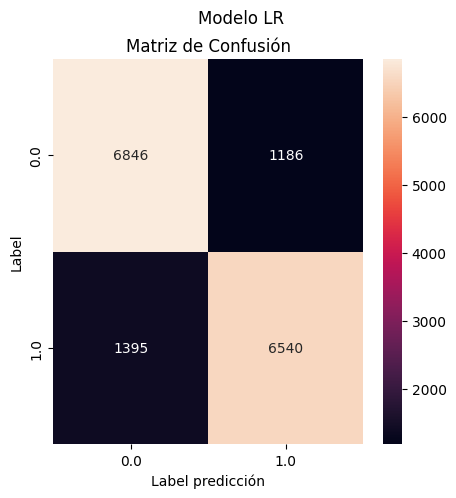

[Stage 431:============================>                            (2 + 2) / 4]

Resultados de Métricas de Rendimiento: Modelo LR
Precision: 0.839 %
Recall:    0.838 %
Accuracy:  0.838 %
f1ScoreLR:  0.838 %


In [79]:
# Se crea la matrix de confusión: predicción en datos de prueba con modelo LR
primerModelo = "Modelo LR"
confMatrixLR = predLR.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixLR, primerModelo)

# Cálculo de las métricas del modelo LR usando el evaluador MultiClase
accuracyLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "accuracy"})
precisionLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedPrecision"})
recallLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedRecall"})
f1ScoreLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "f1"})

# Impresión de las métricas
print(f"Resultados de Métricas de Rendimiento: Modelo LR")
print(f"Precision: {round(precisionLR,3)} %")
print(f"Recall:    {round(recallLR,3)} %")
print(f"Accuracy:  {round(accuracyLR,3)} %")
print(f"f1ScoreLR:  {round(f1ScoreLR,3)} %")

#####  **Curva ROC**: modelo LR

0.9142804490921002
areaUnderROC


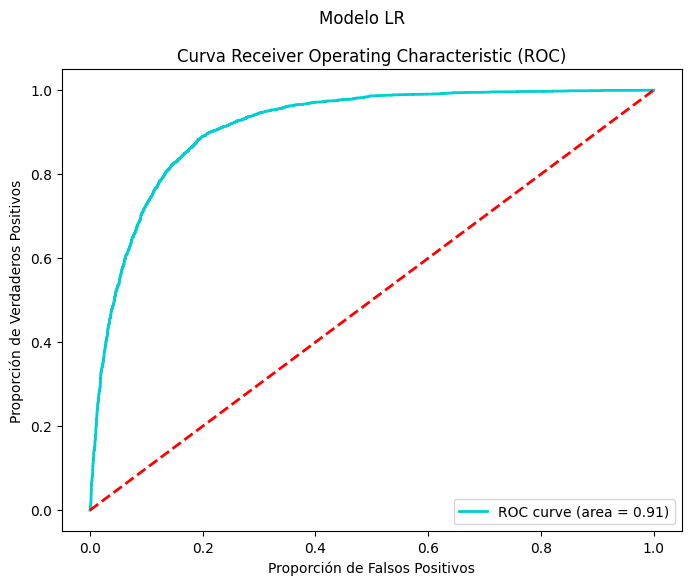

In [80]:
# Se crea un evaluador para métricas de clasificación binaria (área sobre la curva ROC)
evaluadorBinLR = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Se calcula y se presenta la gráfica ROC con predicciones
rocLR = evaluadorBinLR.evaluate(predLR)
print(rocLR)
print(evaluadorBinLR.getMetricName())

plotROC(predLR,rocLR, primerModelo)

### **Segundo Modelo:** Decision Tree:
El modelo Decision Tree permite clasificar clientes mediante reglas de decisión construidas a partir de las variables del dataset. Su principal ventaja es la facilidad de interpretación, ya que muestra de forma clara cómo las características de los clientes influyen en la predicción final. Además, es útil para identificar variables importantes en problemas de clasificación.

**Creación de objeto entrenado:** modelo DT.

In [81]:
from pyspark.ml.classification import DecisionTreeClassifier
instanciaDT = DecisionTreeClassifier(labelCol= 'label', featuresCol="features")

# Entrenamiento del modelo con Datos de Entrenamiento
modeloDT = instanciaDT.fit(trainData)

##### **Predicción** sobre el objeto entrenado: modelo DT.

In [82]:
# Predicción sobre los datos de prueba
predDT = modeloDT.transform(testData)
# se presentan las 10 primeras predicciones del modelo LR
predDT.select("label", "prediction", "probability").show(10)

[Stage 460:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.84489971964632...|
|  0.0|       0.0|[0.84489971964632...|
|  0.0|       0.0|[0.93236409608091...|
|  0.0|       0.0|[0.93236409608091...|
|  0.0|       0.0|[0.93236409608091...|
|  0.0|       0.0|[0.84489971964632...|
|  0.0|       0.0|[0.84489971964632...|
|  0.0|       0.0|[0.84489971964632...|
|  0.0|       0.0|[0.60096805421103...|
|  0.0|       0.0|[0.84489971964632...|
+-----+----------+--------------------+
only showing top 10 rows



##### **Creación del "evaluador"**: Evaluador para métricas de clasificación multiclase.

In [83]:
evaluadorDT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

##### **Matrix de Confusión y Métricas de Rendimiento**: modelo DT.

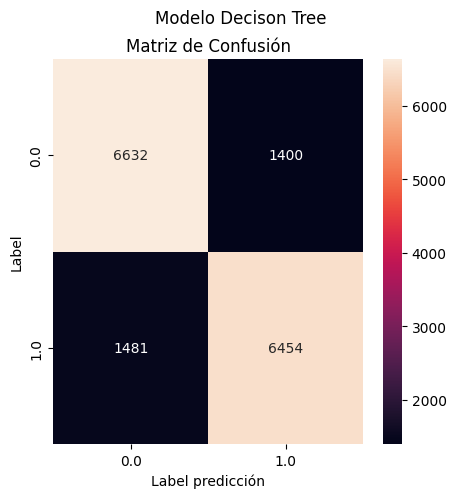

[Stage 767:==========================================>              (3 + 1) / 4]

Resultados de Métricas de Rendimiento: Modelo DT
Precision: 0.82 %
Recall:    0.82 %
Accuracy:  0.82 %


In [95]:
# Se crea la matrix de confusión: predicción en datos de prueba con modelo DT
segundoModelo = "Modelo Decison Tree"
confMatrixDT = predDT.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixDT, segundoModelo)

# Cálculo de las métricas del modelo LR usando el evaluador MultiClase
accuracyDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "accuracy"})
precisionDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "weightedPrecision"})
recallDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "weightedRecall"})
f1ScoreDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "f1"})

# Impresión de las métricas
print(f"Resultados de Métricas de Rendimiento: Modelo DT")
print(f"Precision: {round(precisionDT,3)} %")
print(f"Recall:    {round(recallDT,3)} %")
print(f"Accuracy:  {round(accuracyDT,3)} %")

##### **Curva ROC**: modelo DT.

0.6908379242952574
areaUnderROC


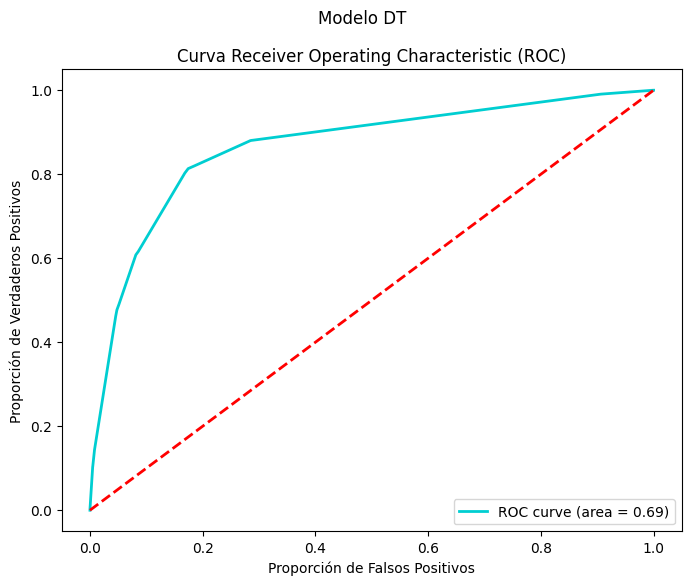

In [85]:
# Se crea un evaluador para métricas de clasificación binaria (área sobre la curva ROC)
evaluadorBinDT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Se calcula y se presenta la gráfica ROC con predicciones
rocDT = evaluadorBinDT.evaluate(predDT)
print(rocDT)
print(evaluadorBinDT.getMetricName())

plotROC(predDT,rocDT,segundoModelo)

### **Tercer Modelo:** Random Forest:


In [86]:
from pyspark.ml.classification import RandomForestClassifier

instanciaRF = RandomForestClassifier(
    featuresCol='features',
    labelCol='label',
    numTrees=100,
    seed=42
)
modeloRF = instanciaRF.fit(trainData)
predRF   = modeloRF.transform(testData)

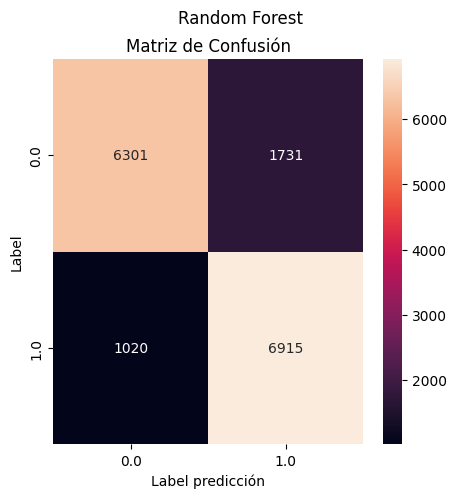

In [87]:
# --- Matriz de Confusión Random Forest ---
confMatrixRF = predRF.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixRF, "Random Forest")

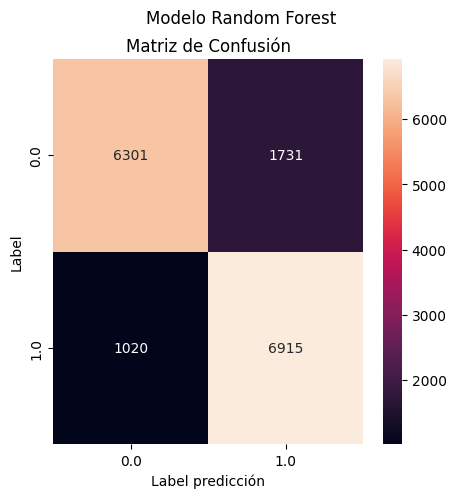

[Stage 797:============================>                            (2 + 2) / 4]

Métricas Random Forest
Accuracy: 0.828
Precision: 0.83
Recall: 0.828
F1 Score: 0.827


In [97]:
evaluadorRF = MulticlassClassificationEvaluator(labelCol = 'label', predictionCol = 'prediction')

#Matriz de Confusión
segundoModelo = 'Modelo Random Forest'
confMatrixRF = predRF.groupBy('label', 'prediction').count()
plotMatConfusion(confMatrixRF, segundoModelo)

#Métricas
accuracyRF = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: 'accuracy'})
precisionRF = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: 'weightedPrecision'})
recallRF = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: 'weightedRecall'})
f1ScoreRF = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: 'f1'})

print(f'Métricas Random Forest')
print(f'Accuracy: {round(accuracyRF, 3)}')
print(f'Precision: {round(precisionRF, 3)}')
print(f'Recall: {round(recallRF, 3)}')
print(f'F1 Score: {round(f1ScoreRF, 3)}')

AUC-ROC RF: 0.903


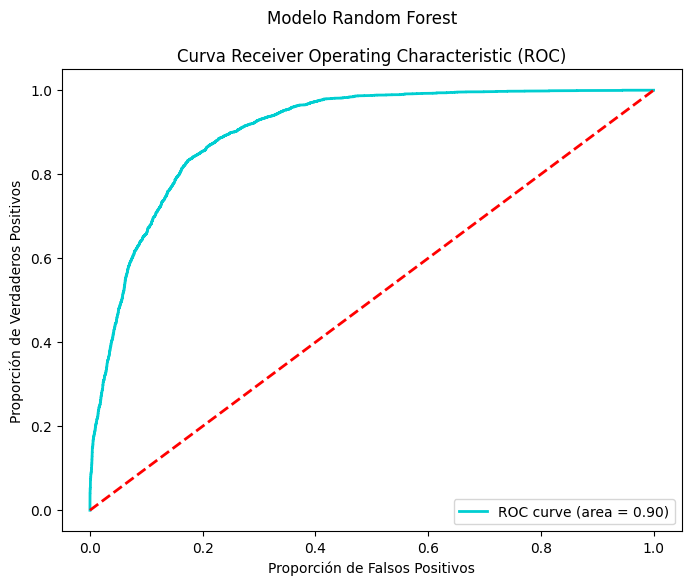

In [89]:
#Curva ROC
evaluadorBinRF = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocRF = evaluadorBinRF.evaluate(predRF)
print(f'AUC-ROC RF: {round(rocRF, 3)}')

plotROC(predRF, rocRF, segundoModelo)

### **Cuarto Modelo:** Gradient Boosted Tree (GBT)


In [91]:
from pyspark.ml.classification import GBTClassifier

instanciaGBT = GBTClassifier(
    featuresCol='features',
    labelCol='label',
    maxIter=10,
    seed=42
)
modeloGBT = instanciaGBT.fit(trainData)
predGBT   = modeloGBT.transform(testData)

In [92]:
# Métricas
accuracyGBT  = evaluadorLR.evaluate(predGBT, {evaluadorLR.metricName: "accuracy"})
precisionGBT = evaluadorLR.evaluate(predGBT, {evaluadorLR.metricName: "weightedPrecision"})
recallGBT    = evaluadorLR.evaluate(predGBT, {evaluadorLR.metricName: "weightedRecall"})
f1GBT        = evaluadorLR.evaluate(predGBT, {evaluadorLR.metricName: "f1"})

evaluadorBinGBT = BinaryClassificationEvaluator(labelCol='label',rawPredictionCol='rawPrediction',metricName='areaUnderROC'
)
aucGBT = evaluadorBinGBT.evaluate(predGBT)

print(" Métricas Gradient Boosted Trees: ")
print(f"Accuracy  : {accuracyGBT:.4f}")
print(f"Precision : {precisionGBT:.4f}")
print(f"Recall    : {recallGBT:.4f}")
print(f"F1-Score  : {f1GBT:.4f}")
print(f"AUC-ROC   : {aucGBT:.4f}")

 Métricas Gradient Boosted Trees: 
Accuracy  : 0.8427
Precision : 0.8438
Recall    : 0.8427
F1-Score  : 0.8426
AUC-ROC   : 0.9170


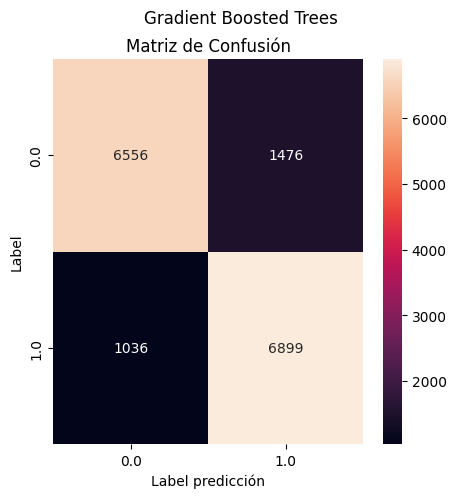

In [93]:
# Matriz de Confusión 
confMatrixGBT = predGBT.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixGBT, "Gradient Boosted Trees")

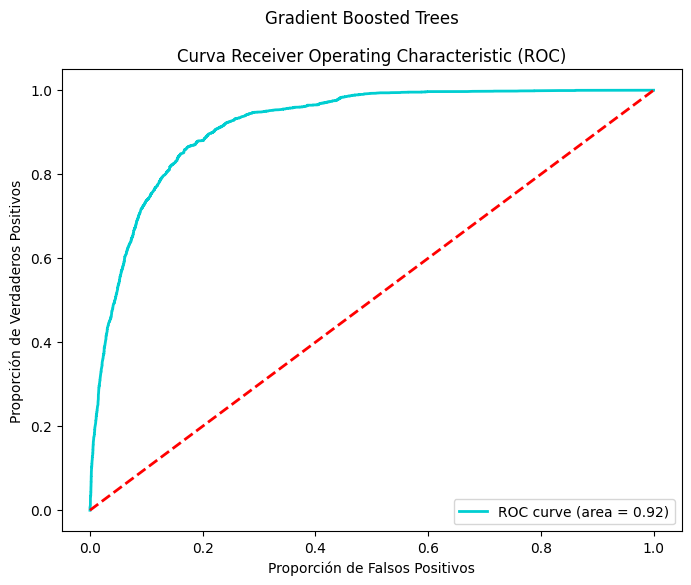

In [94]:
# Curva ROC 
plotROC(predGBT, aucGBT, "Gradient Boosted Trees")

### **Quinto Modelo:** Support Vector Machine (SVM)



In [99]:

from pyspark.ml.classification import LinearSVC

# Create and train the SVM model
instanciaSVM = LinearSVC(
    featuresCol = 'features',
    labelCol = 'label',
    maxIter = 100,     
    regParam = 0.01
)
modeloSVM = instanciaSVM.fit(trainData)


In [100]:
predSVM = modeloSVM.transform(testData)
predSVM.select('label', 'prediction', 'rawPrediction').show(5)

[Stage 947:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|       rawPrediction|
+-----+----------+--------------------+
|  0.0|       0.0|[0.83104235314756...|
|  0.0|       0.0|[0.63476762493212...|
|  0.0|       0.0|[0.84031621013400...|
|  0.0|       0.0|[1.58667927316625...|
|  0.0|       0.0|[1.40484605918293...|
+-----+----------+--------------------+
only showing top 5 rows



In [101]:
predSVM = modeloSVM.transform(testData)
predSVM.select('label', 'prediction', 'rawPrediction').show(5)

[Stage 948:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|       rawPrediction|
+-----+----------+--------------------+
|  0.0|       0.0|[0.83104235314756...|
|  0.0|       0.0|[0.63476762493212...|
|  0.0|       0.0|[0.84031621013400...|
|  0.0|       0.0|[1.58667927316625...|
|  0.0|       0.0|[1.40484605918293...|
+-----+----------+--------------------+
only showing top 5 rows



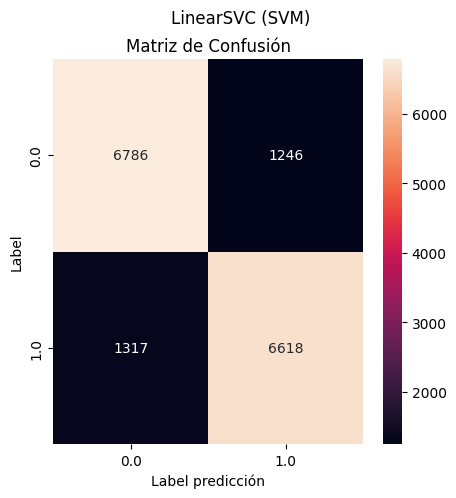

[Stage 969:============================>                            (2 + 2) / 4]

 Métricas de LinearSVC (SVM)
Accuracy: 0.839
Precision: 0.839
Recall: 0.839
F1 Score: 0.839


In [103]:
evaluadorSVM = MulticlassClassificationEvaluator(labelCol = 'label', predictionCol = 'prediction')

# Matriz de Confusión
tercerModelo = 'LinearSVC (SVM)'
confMatrixSVM = predSVM.groupBy('label', 'prediction').count()
plotMatConfusion(confMatrixSVM, tercerModelo)

# Calculate metrics
accuracySVM = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: 'accuracy'})
precisionSVM = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: 'weightedPrecision'})
recallSVM = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: 'weightedRecall'})
f1ScoreSVM = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: 'f1'})

print(f' Métricas de LinearSVC (SVM)')
print(f'Accuracy: {round(accuracySVM, 3)}')
print(f'Precision: {round(precisionSVM, 3)}')
print(f'Recall: {round(recallSVM, 3)}')
print(f'F1 Score: {round(f1ScoreSVM, 3)}')

AUC-ROC SVM: 0.915


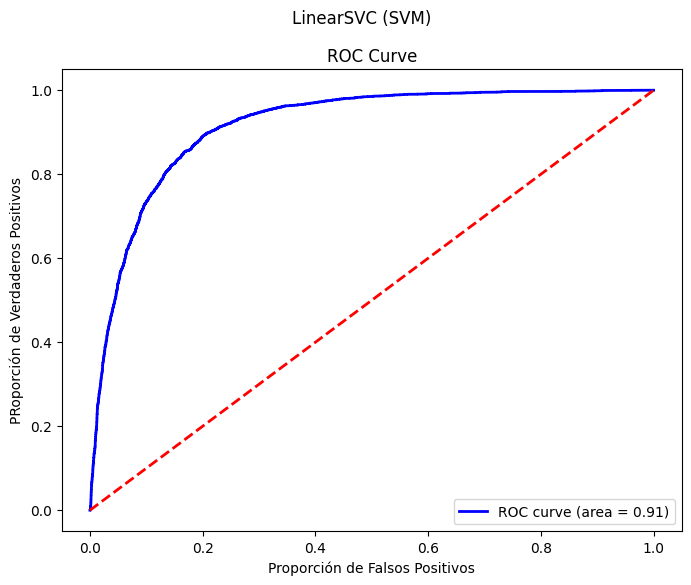

In [105]:
# Curva ROC (SVM) 
evaluadorBinSVM = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocSVM = evaluadorBinSVM.evaluate(predSVM)
print(f'AUC-ROC SVM: {round(rocSVM, 3)}')

# For the ROC plot, extract the signed margin (rawPrediction[1] - rawPrediction[0])
probsSVM = predSVM.select('rawPrediction').rdd.map(lambda row: float(row['rawPrediction'][1]))
labelsSVM = predSVM.select('label').rdd.map(lambda row: row['label'])
fpr_svm, tpr_svm, _ = roc_curve(labelsSVM.collect(), probsSVM.collect())

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, color='blue', lw=2, label=f'ROC curve (area = {rocSVM:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlabel('Proporción de Falsos Positivos')
plt.ylabel('PRoporción de Verdaderos Positivos')
plt.title('ROC Curve')
plt.suptitle(tercerModelo)
plt.legend(loc='lower right')
plt.show()

### **10. Evaluación de los modelos**

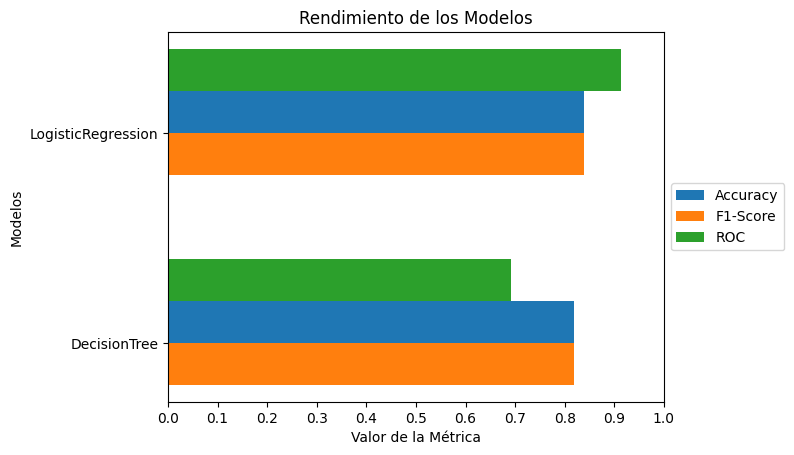

In [106]:
# Datos generales
modelos  = ['LogisticRegression', 'DecisionTree','Random Forest', 'LinearSVC (SVM)', 'Gradient Boosting']
accuracy = [accuracyLR, accuracyDT]
f1Score  = [f1ScoreLR, f1ScoreDT]
curvaROC = [rocLR, rocDT]

# Se ordenan los valores según la curva ROC
modelos, f1Score, accuracy, curvaROC = zip(*sorted(zip(modelos, f1Score, accuracy, curvaROC), key=lambda x: x[3]))

# Definición de longitud de barras
longitud = 0.2

# Posición de las barras en horizontal
posHorizontal = np.arange(len(modelos))

# Plotagem do gráfico de barras horizontais
barra1 = plt.barh(posHorizontal + 0.1, accuracy, longitud, label='Accuracy')
barra2 = plt.barh(posHorizontal - 0.1, f1Score, longitud, label='F1-Score')
barra3 = plt.barh(posHorizontal + longitud + 0.1, curvaROC, longitud, label='ROC')

# Configuración del gráfico
plt.ylabel('Modelos')
plt.xlabel('Valor de la Métrica')
plt.title('Rendimiento de los Modelos')
plt.yticks(posHorizontal, modelos)
plt.xticks(np.arange(0, 1.1, 0.1))


# Se agregan las leyendas de métricas
plt.legend(handles=[barra1, barra2, barra3], loc='center left', bbox_to_anchor=(1, 0.5), labels=['Accuracy', 'F1-Score', 'ROC'])

# Se presenta el gráfico
plt.show()

In [110]:
resultados = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'LinearSVC (SVM)', 'Gradient Boosting'],
    'Accuracy': [accuracyLR, accuracyDT, accuracyRF, accuracySVM, accuracyGBT],
    'Precision': [precisionLR, precisionDT, precisionRF, precisionSVM, precisionGBT],
    'Recall': [recallLR, recallDT, recallRF, recallSVM, recallGBT],
    'F1-Score': [f1ScoreLR, f1ScoreDT, f1ScoreRF,   f1ScoreSVM,   f1GBT],
    'AUC-ROC': [rocLR, rocDT, rocRF, rocSVM, aucGBT]
})

# Sort by AUC-ROC descending
resultados = resultados.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
print(resultados.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1-Score  AUC-ROC
  Gradient Boosting  0.842676   0.843772 0.842676  0.842582 0.917020
    LinearSVC (SVM)  0.839481   0.839500 0.839481  0.839474 0.914725
Logistic Regression  0.838354   0.838560 0.838354  0.838314 0.914280
      Random Forest  0.827707   0.830418 0.827707  0.827412 0.903167
      Decision Tree  0.819565   0.819587 0.819565  0.819555 0.690838


In [111]:
sparkGomez.stop()

### ***11. Conclusiones:***


### Referencias:
- Apache Software Foundation. (2024). *Random Forest*. https://spark.apache.org/docs/latest/ml-classification-regression.html#random-forest-classifier

- Apache Software Foundation. (2024). *Gradient Boosted Trees*. https://spark.apache.org/docs/latest/ml-classification-regression.html#gradient-boosted-tree-classifier

- Apache Software Foundation. (2024). *Gradient Boosted Trees*. https://spark.apache.org/docs/latest/ml-classification-regression.html#gradient-boosted-tree-classifier

- Apache Software Foundation. (2024). *Decision Tree*. https://spark.apache.org/docs/latest/ml-classification-regression.html#decision-tree-classifier

- Apache Software Foundation. (2024). *Linear Support Vector Machine*. https://spark.apache.org/docs/latest/ml-classification-regression.html#linear-support-vector-machine

- Apache Software Foundation. (2024). *Multilayer Perceptron Classifier*. https://spark.apache.org/docs/latest/ml-classification-regression.html#multilayer-perceptron-classifier

- UCI Machine Learning Repository. (2012). Bank Marketing Dataset. https://archive.ics.uci.edu/dataset/222/bank+marketing

- Moro, S., Rita, P., & Cortez, P. (2014). Bank Marketing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5K306

- Moro, S., Cortez, P., & Rita, P. (2014). A Data-Driven Approach to Predict the Success of Bank Telemarketing. *Decision Support Systems*, Elsevier, 62, 22-31.

- Apache Software Foundation. (2024). *Logistic Regression*. https://spark.apache.org/docs/latest/ml-classification-regression.html#logistic-regression